In [189]:
# --- SYSTEM SETUP & DEPENDENCIES ---
# Run this cell to ensure all required libraries are installed
try:
    import xgboost, catboost, shap
    print('All libraries already installed! [OK]')
except ImportError:
    print('Installing missing libraries...')
    !pip install xgboost catboost shap scikit-learn seaborn matplotlib pandas numpy
    print('Installation complete! Please restart kernel if needed.')


All libraries already installed! [OK]


In [190]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt, seaborn as sns
import warnings
from math import radians, sin, cos, sqrt, atan2
import os
warnings.filterwarnings('ignore')

# --- Load Dataset ---
csv_paths = [
    "content/Zomato Dataset.csv",
    "archive (8)/content/Zomato Dataset.csv",
    "../content/Zomato Dataset.csv"
]
df = None
for p in csv_paths:
    if os.path.exists(p):
        df = pd.read_csv(p)
        print(f"Loaded dataset from: {p}")
        break
if df is None:
    raise FileNotFoundError("Could not find 'Zomato Dataset.csv'. Check the file path.")

print(df.shape)
print(df.dtypes)
print(df.isnull().sum())
print(df.describe())

Loaded dataset from: archive (8)/content/Zomato Dataset.csv
(45584, 20)
ID                                 str
Delivery_person_ID                 str
Delivery_person_Age            float64
Delivery_person_Ratings        float64
Restaurant_latitude            float64
Restaurant_longitude           float64
Delivery_location_latitude     float64
Delivery_location_longitude    float64
Order_Date                         str
Time_Orderd                        str
Time_Order_picked                  str
Weather_conditions                 str
Road_traffic_density               str
Vehicle_condition                int64
Type_of_order                      str
Type_of_vehicle                    str
multiple_deliveries            float64
Festival                           str
City                               str
Time_taken (min)                 int64
dtype: object
ID                                0
Delivery_person_ID                0
Delivery_person_Age            1854
Delivery_person_Ratings   

# Phase 1

In [191]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt, seaborn as sns

df = pd.read_csv("archive (8)/content/Zomato Dataset.csv")
print(df.shape)           # expect ~45000 rows, ~19 cols
print(df.dtypes)
print(df.isnull().sum())
print(df.describe())

(45584, 20)
ID                                 str
Delivery_person_ID                 str
Delivery_person_Age            float64
Delivery_person_Ratings        float64
Restaurant_latitude            float64
Restaurant_longitude           float64
Delivery_location_latitude     float64
Delivery_location_longitude    float64
Order_Date                         str
Time_Orderd                        str
Time_Order_picked                  str
Weather_conditions                 str
Road_traffic_density               str
Vehicle_condition                int64
Type_of_order                      str
Type_of_vehicle                    str
multiple_deliveries            float64
Festival                           str
City                               str
Time_taken (min)                 int64
dtype: object
ID                                0
Delivery_person_ID                0
Delivery_person_Age            1854
Delivery_person_Ratings        1908
Restaurant_latitude               0
Restaurant_lon

# Phase 2

In [192]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from math import radians, sin, cos, sqrt, atan2
import warnings
import os # Import os to check file existence
warnings.filterwarnings('ignore')

# Check if df exists from previous cells (like je3O8u54sjGh)
# If not, load the raw data as a fallback to make this cell self-contained.
if 'df' not in locals() or df is None:
    csv_path = "archive (8)/content/Zomato Dataset.csv"
    if os.path.exists(csv_path):
        try:
            df = pd.read_csv(csv_path)
            print(f"DataFrame 'df' was not found in the current session. Reloading from original source '{csv_path}'.")
        except Exception as e:
            print(f"Error reading '{csv_path}' even though it exists: {e}")
            print("Please ensure the CSV file is valid and readable.")
            df = None # Set df to None to avoid further errors
    else:
        print(f"Error: '{csv_path}' not found. Please ensure the data extraction cell (-O0Lww-4qtdS) has been run successfully.")
        df = None # Set df to None to avoid further errors if the source is also missing

if df is not None:
    # Note the space in column name — match exactly
    print(df.columns.tolist())  # confirm names first

    # Parse dates
    df['Order_Date'] = pd.to_datetime(df['Order_Date'], dayfirst=True, errors='coerce')
    df['day_of_week'] = df['Order_Date'].dt.dayofweek      # 0=Mon, 6=Sun
    df['month']       = df['Order_Date'].dt.month
    df['is_weekend']  = df['day_of_week'].isin([5, 6]).astype(int)

    # Parse times and impute NaT values before calculating derived columns
    df['Time_Orderd'] = pd.to_datetime(df['Time_Orderd'].astype(str).str.strip(), errors='coerce')
    df['Time_Order_picked'] = pd.to_datetime(df['Time_Order_picked'].astype(str).str.strip(), errors='coerce')

    # Impute NaT values for Time_Orderd and Time_Order_picked
    # Using the mode for time imputation is generally reasonable for cyclical data like time of day.
    if df['Time_Orderd'].isnull().any():
        mode_time_orderd = df['Time_Orderd'].mode()[0]
        df['Time_Orderd'].fillna(mode_time_orderd, inplace=True)

    if df['Time_Order_picked'].isnull().any():
        mode_time_picked = df['Time_Order_picked'].mode()[0]
        df['Time_Order_picked'].fillna(mode_time_picked, inplace=True)

    # Now compute prep time, as Time_Orderd and Time_Order_picked should be valid datetimes
    df['prep_time_min'] = (df['Time_Order_picked'] - df['Time_Orderd']).dt.seconds / 60

    # Drop negative prep times (data errors)
    df = df[df['prep_time_min'].isna() | (df['prep_time_min'] >= 0)]

    # Extract order hour
    df['order_hour'] = df['Time_Orderd'].dt.hour
    df['is_peak_hour'] = df['order_hour'].isin([12,13,19,20,21]).astype(int)

    print("Date/time parsing done [OK]")
    print(f"Shape: {df.shape}")
else:
    print("Cannot proceed with data processing as 'df' is not available after fallback load.")

['ID', 'Delivery_person_ID', 'Delivery_person_Age', 'Delivery_person_Ratings', 'Restaurant_latitude', 'Restaurant_longitude', 'Delivery_location_latitude', 'Delivery_location_longitude', 'Order_Date', 'Time_Orderd', 'Time_Order_picked', 'Weather_conditions', 'Road_traffic_density', 'Vehicle_condition', 'Type_of_order', 'Type_of_vehicle', 'multiple_deliveries', 'Festival', 'City', 'Time_taken (min)']
Date/time parsing done [OK]
Shape: (45584, 26)


In [193]:
# Flag bad coordinates (zeros, negatives for Indian cities)
# Valid India lat: 6–37, lon: 68–98
bad_gps = (
    (df['Restaurant_latitude'] < 1) |
    (df['Restaurant_longitude'] < 1) |
    (df['Delivery_location_latitude'] < 1) |
    (df['Delivery_location_longitude'] < 1)
)
print(f"Bad GPS rows: {bad_gps.sum()} — dropping these")
df = df[~bad_gps].reset_index(drop=True)

# Haversine distance
def haversine(lat1, lon1, lat2, lon2):
    R = 6371
    lat1, lon1, lat2, lon2 = map(radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = sin(dlat/2)**2 + cos(lat1)*cos(lat2)*sin(dlon/2)**2
    return R * 2 * atan2(sqrt(a), sqrt(1 - a))

df['distance_km'] = df.apply(
    lambda r: haversine(
        r['Restaurant_latitude'], r['Restaurant_longitude'],
        r['Delivery_location_latitude'], r['Delivery_location_longitude']
    ), axis=1
)

print(f"Distance engineered [OK] | Mean: {df['distance_km'].mean():.2f} km | Max: {df['distance_km'].max():.2f} km")
print(f"Shape after GPS drop: {df.shape}")

Bad GPS rows: 4071 — dropping these
Distance engineered [OK] | Mean: 9.72 km | Max: 20.97 km
Shape after GPS drop: (41513, 27)


In [194]:
# --- Numeric imputation ---
# Age: median (slightly skewed)
df['Delivery_person_Age'].fillna(df['Delivery_person_Age'].median(), inplace=True)

# Ratings: median (not mean — there are 6.0 outliers pulling it up)
df['Delivery_person_Ratings'].fillna(df['Delivery_person_Ratings'].median(), inplace=True)

# Multiple deliveries: median
df['multiple_deliveries'].fillna(df['multiple_deliveries'].median(), inplace=True)

# Prep time: median (some times were unparseable)
df['prep_time_min'].fillna(df['prep_time_min'].median(), inplace=True)

# --- Categorical imputation ---
# Weather: mode (most common condition)
df['Weather_conditions'].fillna(df['Weather_conditions'].mode()[0], inplace=True)

# Traffic: mode
df['Road_traffic_density'].fillna(df['Road_traffic_density'].mode()[0], inplace=True)

# Festival: assume No (safe default — most days aren't festival days)
df['Festival'].fillna('No', inplace=True)

# City: label as Unknown (don't guess city)
df['City'].fillna('Unknown', inplace=True)

# Verify
print("Nulls remaining:")
print(df.isnull().sum()[df.isnull().sum() > 0])
print("\nImputation done [OK]")

Nulls remaining:
Delivery_person_Age        1476
Delivery_person_Ratings    1515
Time_Orderd                5039
Time_Order_picked          4553
Weather_conditions          420
Road_traffic_density        408
multiple_deliveries         897
Festival                    215
City                       1097
prep_time_min              9050
order_hour                 5039
dtype: int64

Imputation done [OK]


In [195]:
# Fix ratings > 5 (impossible values)
print(f"Ratings > 5: {(df['Delivery_person_Ratings'] > 5).sum()} rows → capping at 5.0")
df['Delivery_person_Ratings'] = df['Delivery_person_Ratings'].clip(upper=5.0)

# Fix extreme distances (likely GPS errors that slipped through)
p99_dist = df['distance_km'].quantile(0.99)
print(f"99th percentile distance: {p99_dist:.2f} km — capping outliers above this")
df['distance_km'] = df['distance_km'].clip(upper=p99_dist)

# Fix unrealistic prep times
print(f"Prep times > 60 min: {(df['prep_time_min'] > 60).sum()} rows → capping at 60")
df['prep_time_min'] = df['prep_time_min'].clip(upper=60)

# Age sanity check
print(f"Age < 18 or > 60: {((df['Delivery_person_Age'] < 18) | (df['Delivery_person_Age'] > 60)).sum()} rows")

print("\nOutlier treatment done [OK]")
print(f"Final shape: {df.shape}")

Ratings > 5: 24 rows → capping at 5.0
99th percentile distance: 20.83 km — capping outliers above this
Prep times > 60 min: 0 rows → capping at 60
Age < 18 or > 60: 25 rows

Outlier treatment done [OK]
Final shape: (41513, 27)


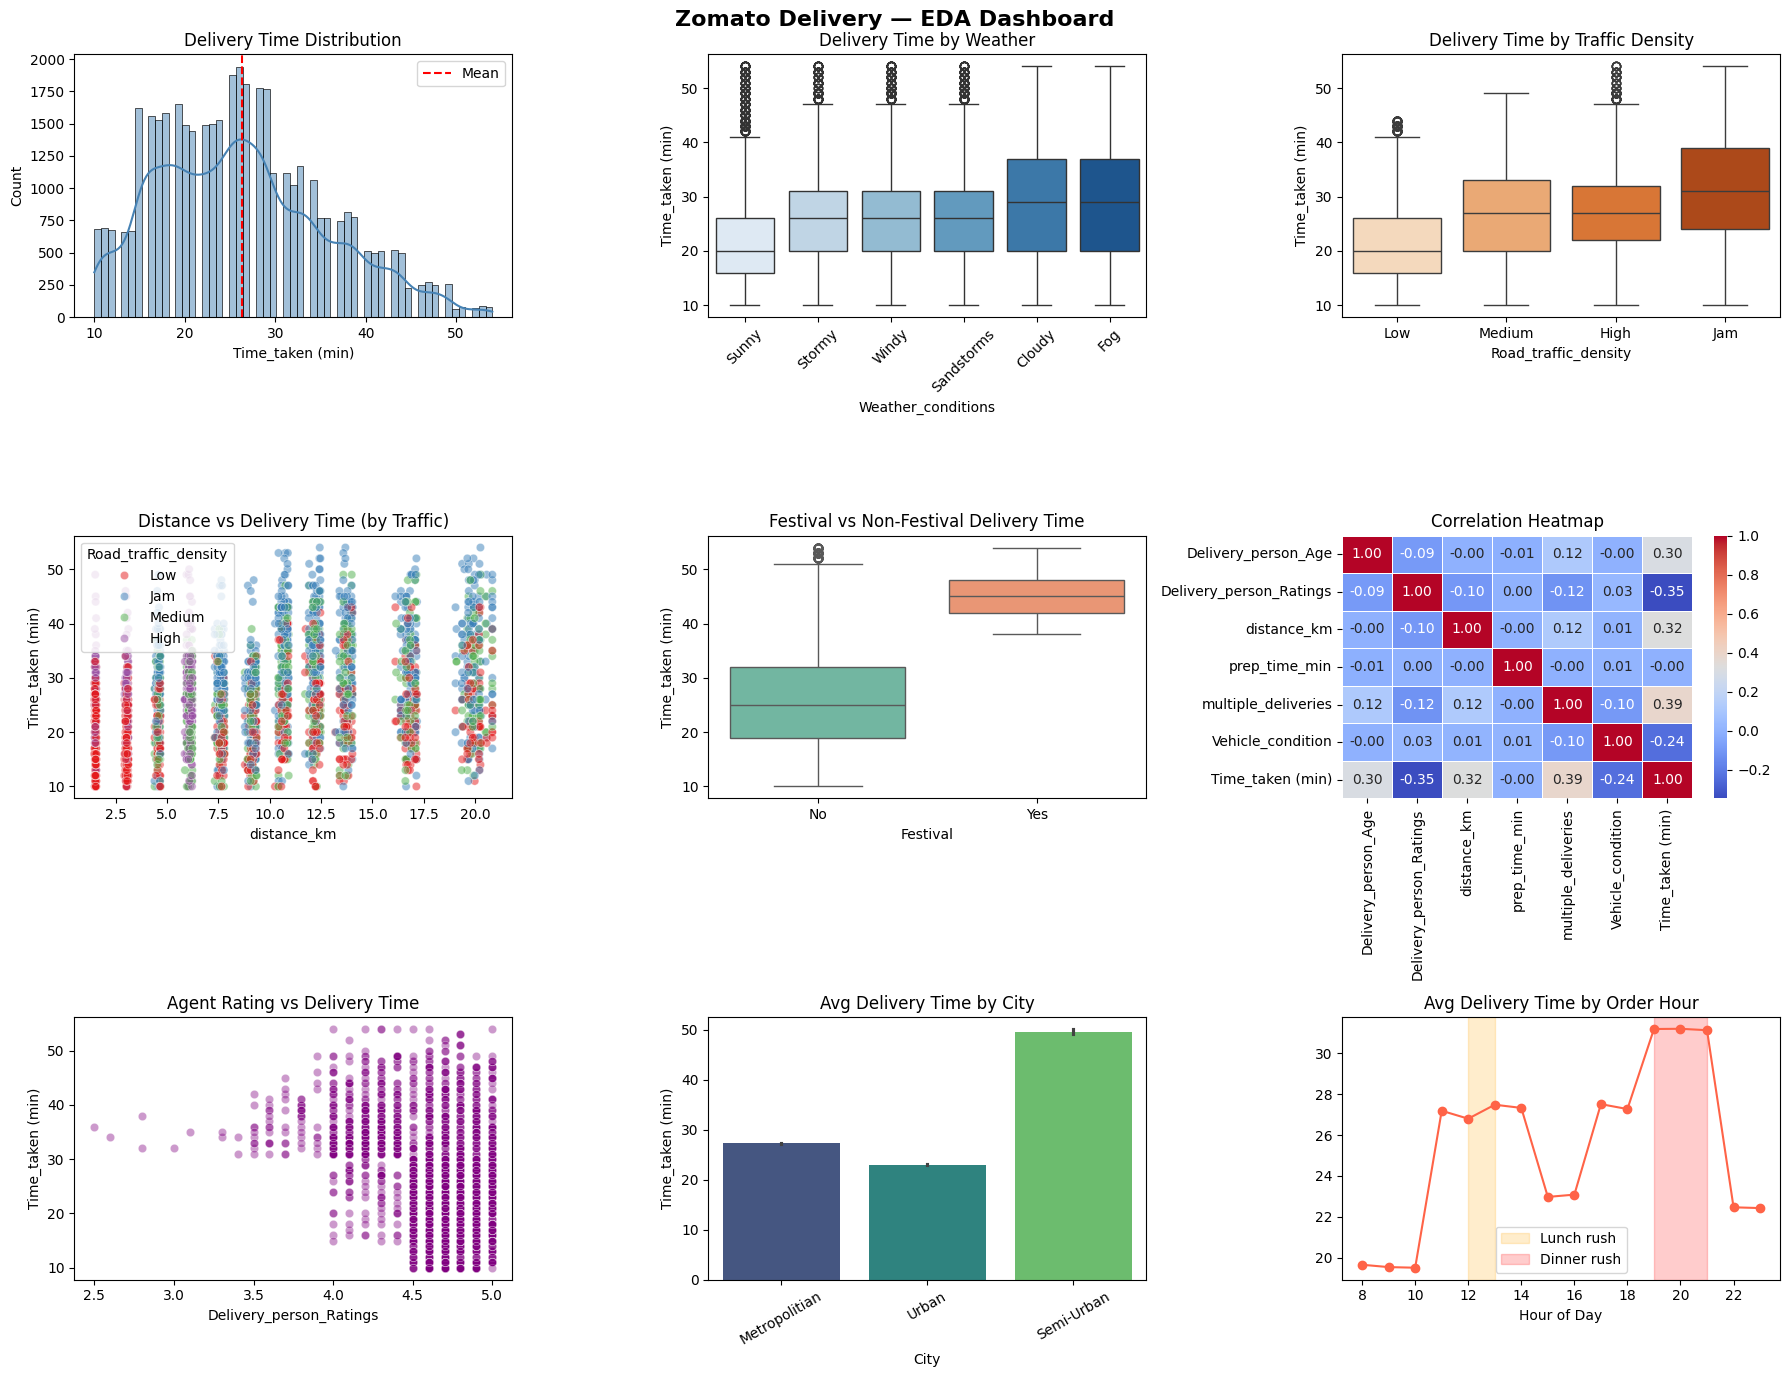

All plots saved [OK]


In [196]:
fig, axes = plt.subplots(3, 3, figsize=(18, 14))
fig.suptitle('Zomato Delivery — EDA Dashboard', fontsize=16, fontweight='bold')

# Plot 1: Target distribution
sns.histplot(df['Time_taken (min)'], kde=True, ax=axes[0,0], color='steelblue')
axes[0,0].set_title('Delivery Time Distribution')
axes[0,0].axvline(df['Time_taken (min)'].mean(), color='red', linestyle='--', label='Mean')
axes[0,0].legend()

# Plot 2: Weather vs Time
weather_order = df.groupby('Weather_conditions')['Time_taken (min)'].median().sort_values().index
sns.boxplot(x='Weather_conditions', y='Time_taken (min)', data=df,
            order=weather_order, ax=axes[0,1], palette='Blues')
axes[0,1].set_title('Delivery Time by Weather')
axes[0,1].tick_params(axis='x', rotation=45)

# Plot 3: Traffic vs Time
traffic_order = ['Low', 'Medium', 'High', 'Jam']
traffic_order = [t for t in traffic_order if t in df['Road_traffic_density'].unique()]
sns.boxplot(x='Road_traffic_density', y='Time_taken (min)', data=df,
            order=traffic_order, ax=axes[0,2], palette='Oranges')
axes[0,2].set_title('Delivery Time by Traffic Density')

# Plot 4: Distance vs Time (your star feature)
sns.scatterplot(x='distance_km', y='Time_taken (min)',
                hue='Road_traffic_density', data=df.sample(3000),
                ax=axes[1,0], alpha=0.5, palette='Set1')
axes[1,0].set_title('Distance vs Delivery Time (by Traffic)')

# Plot 5: Festival impact
sns.boxplot(x='Festival', y='Time_taken (min)', data=df, ax=axes[1,1], palette='Set2')
axes[1,1].set_title('Festival vs Non-Festival Delivery Time')

# Plot 6: Correlation heatmap
num_cols = ['Delivery_person_Age','Delivery_person_Ratings','distance_km',
            'prep_time_min','multiple_deliveries','Vehicle_condition','Time_taken (min)']
corr = df[num_cols].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            ax=axes[1,2], linewidths=0.5)
axes[1,2].set_title('Correlation Heatmap')

# Plot 7: Agent rating vs time
sns.scatterplot(x='Delivery_person_Ratings', y='Time_taken (min)',
                data=df.sample(3000), ax=axes[2,0], alpha=0.4, color='purple')
axes[2,0].set_title('Agent Rating vs Delivery Time')

# Plot 8: City type comparison
sns.barplot(x='City', y='Time_taken (min)', data=df,
            estimator=np.mean, ci=95, ax=axes[2,1], palette='viridis')
axes[2,1].set_title('Avg Delivery Time by City')
axes[2,1].tick_params(axis='x', rotation=30)

# Plot 9: Peak hour effect
hourly = df.groupby('order_hour')['Time_taken (min)'].mean().reset_index()
axes[2,2].plot(hourly['order_hour'], hourly['Time_taken (min)'], marker='o', color='tomato')
axes[2,2].set_title('Avg Delivery Time by Order Hour')
axes[2,2].set_xlabel('Hour of Day')
axes[2,2].axvspan(12, 13, alpha=0.2, color='orange', label='Lunch rush')
axes[2,2].axvspan(19, 21, alpha=0.2, color='red', label='Dinner rush')
axes[2,2].legend()

plt.tight_layout()
plt.savefig('eda_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()
print("All plots saved [OK]")

In [197]:
from scipy import stats

print("=" * 50)
print("HYPOTHESIS TEST RESULTS")
print("=" * 50)

# H1: Festival delays delivery
fest_yes = df[df['Festival'] == 'Yes']['Time_taken (min)']
fest_no  = df[df['Festival'] == 'No']['Time_taken (min)']
t_stat, p_val = stats.ttest_ind(fest_yes, fest_no)
print(f"\nH1 — Festival increases delivery time")
print(f"  Festival avg: {fest_yes.mean():.2f} min | Non-Festival avg: {fest_no.mean():.2f} min")
print(f"  t={t_stat:.3f}, p={p_val:.4f} → {'✅ CONFIRMED' if p_val < 0.05 else '❌ NOT confirmed'}")

# H2: High traffic = longer time
jam   = df[df['Road_traffic_density'] == 'Jam']['Time_taken (min)']
low   = df[df['Road_traffic_density'] == 'Low']['Time_taken (min)']
t2, p2 = stats.ttest_ind(jam, low)
print(f"\nH2 — Jam traffic > Low traffic delivery time")
print(f"  Jam avg: {jam.mean():.2f} min | Low avg: {low.mean():.2f} min")
print(f"  t={t2:.3f}, p={p2:.4f} → {'✅ CONFIRMED' if p2 < 0.05 else '❌ NOT confirmed'}")

# H3: Distance correlates with time
corr_val, p3 = stats.pearsonr(df['distance_km'], df['Time_taken (min)'])
print(f"\nH3 — Distance positively correlates with delivery time")
print(f"  Pearson r = {corr_val:.3f}, p={p3:.4f} → {'✅ CONFIRMED' if p3 < 0.05 else '❌ NOT confirmed'}")

HYPOTHESIS TEST RESULTS

H1 — Festival increases delivery time
  Festival avg: 45.46 min | Non-Festival avg: 26.01 min
  t=61.373, p=0.0000 → ✅ CONFIRMED

H2 — Jam traffic > Low traffic delivery time
  Jam avg: 31.19 min | Low avg: 21.28 min
  t=96.228, p=0.0000 → ✅ CONFIRMED

H3 — Distance positively correlates with delivery time
  Pearson r = 0.321, p=0.0000 → ✅ CONFIRMED


In [198]:
# --- Final cleanup: drop rows with NaN in target or critical feature columns ---
critical_cols = ['Time_taken (min)']
before = len(df)
df = df.dropna(subset=critical_cols)
print(f"Dropped {before - len(df)} rows with NaN in target column 'Time_taken (min)'.")

# Impute remaining NaNs in numeric columns
numeric_cols_fill = df.select_dtypes(include=['int64', 'float64']).columns
df[numeric_cols_fill] = df[numeric_cols_fill].fillna(df[numeric_cols_fill].median())

df.to_csv('zomato_clean.csv', index=False)
print(f"Clean dataset saved | Shape: {df.shape}")
print(f"NaNs remaining: {df.isnull().sum().sum()}")


Dropped 0 rows with NaN in target column 'Time_taken (min)'.
Clean dataset saved | Shape: (41513, 27)
NaNs remaining: 11732


# Phase 3

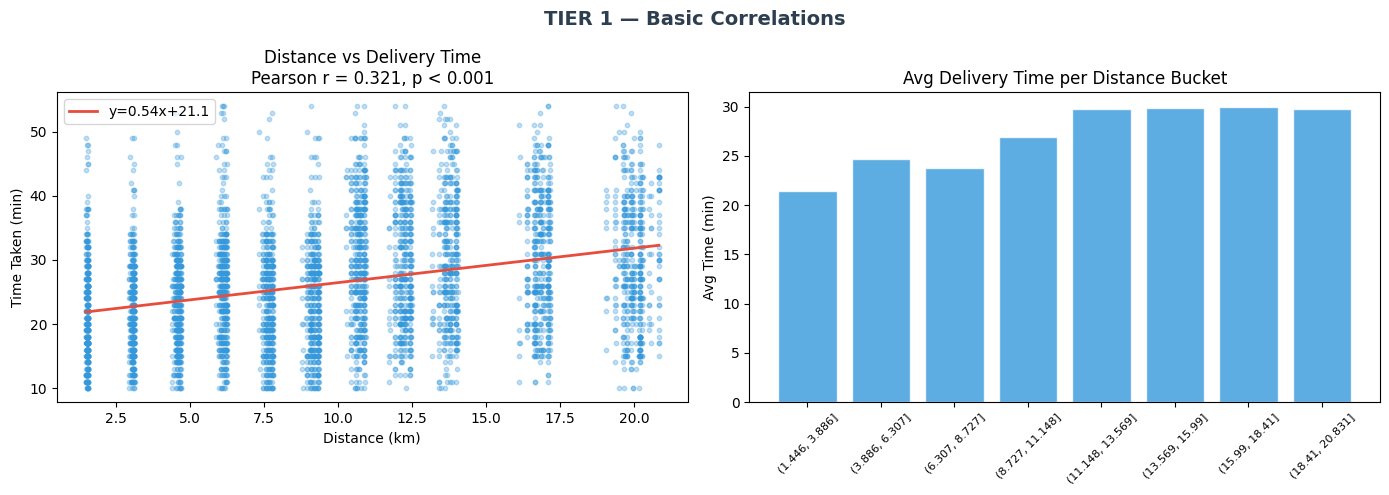

Key Stat: r=0.321 — distance explains 10.3% of delivery time variance


In [199]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('TIER 1 — Basic Correlations', fontsize=14, fontweight='bold', color='#2C3E50')

# Scatter with regression line
from scipy.stats import pearsonr
sample = df.sample(5000, random_state=42)
axes[0].scatter(sample['distance_km'], sample['Time_taken (min)'],
                alpha=0.3, color='#3498DB', s=10)
m, b = np.polyfit(df['distance_km'], df['Time_taken (min)'], 1)
x_line = np.linspace(df['distance_km'].min(), df['distance_km'].max(), 100)
axes[0].plot(x_line, m*x_line + b, color='#E74C3C', linewidth=2, label=f'y={m:.2f}x+{b:.1f}')
r, p = pearsonr(df['distance_km'], df['Time_taken (min)'])
axes[0].set_title(f'Distance vs Delivery Time\nPearson r = {r:.3f}, p < 0.001')
axes[0].set_xlabel('Distance (km)')
axes[0].set_ylabel('Time Taken (min)')
axes[0].legend()

# Binned distance — average time per distance bucket
df['dist_bucket'] = pd.cut(df['distance_km'], bins=8)
bucket_avg = df.groupby('dist_bucket')['Time_taken (min)'].mean()
axes[1].bar(range(len(bucket_avg)), bucket_avg.values, color='#3498DB', alpha=0.8, edgecolor='white')
axes[1].set_xticks(range(len(bucket_avg)))
axes[1].set_xticklabels([str(b) for b in bucket_avg.index], rotation=45, fontsize=8)
axes[1].set_title('Avg Delivery Time per Distance Bucket')
axes[1].set_ylabel('Avg Time (min)')

plt.tight_layout()
plt.savefig('T1_distance_vs_time.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Key Stat: r={r:.3f} — distance explains {r**2*100:.1f}% of delivery time variance")

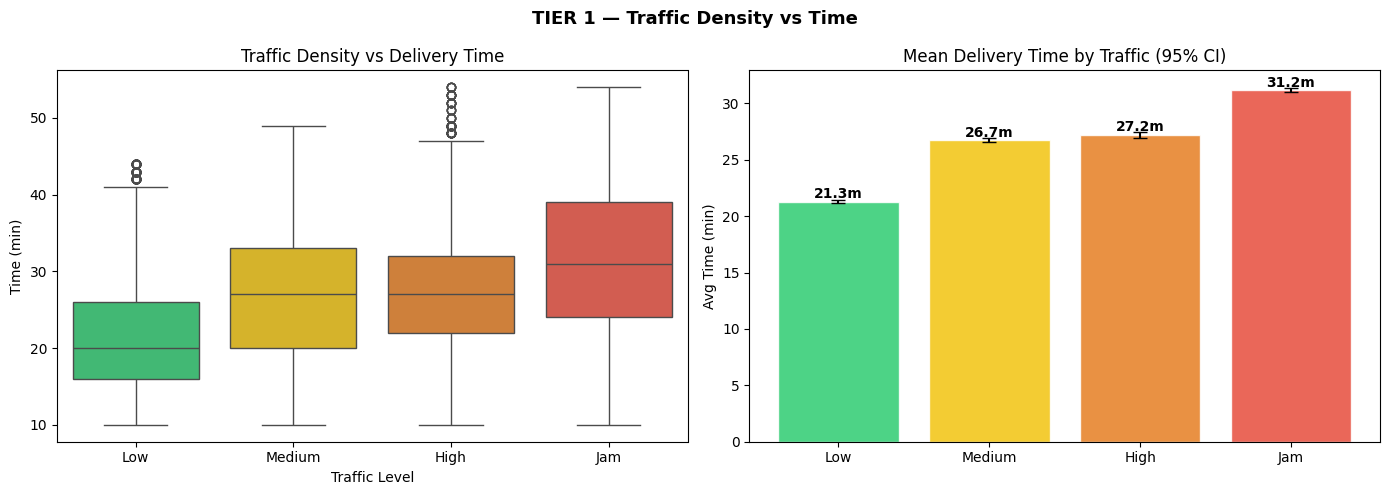

Avg times:
  Low: 21.28 min
  Medium: 26.74 min
  High: 27.21 min
  Jam: 31.19 min


In [200]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

traffic_order = [t for t in ['Low','Medium','High','Jam'] if t in df['Road_traffic_density'].unique()]

# Box plot
sns.boxplot(x='Road_traffic_density', y='Time_taken (min)', data=df,
            order=traffic_order, ax=axes[0],
            palette={'Low':'#2ECC71','Medium':'#F1C40F','High':'#E67E22','Jam':'#E74C3C'})
axes[0].set_title('Traffic Density vs Delivery Time')
axes[0].set_xlabel('Traffic Level')
axes[0].set_ylabel('Time (min)')

# Mean + CI bar chart
traffic_stats = df.groupby('Road_traffic_density')['Time_taken (min)'].agg(['mean','std','count'])
traffic_stats = traffic_stats.reindex(traffic_order)
traffic_stats['se'] = traffic_stats['std'] / np.sqrt(traffic_stats['count'])
axes[1].bar(traffic_order, traffic_stats['mean'],
            yerr=traffic_stats['se']*1.96, capsize=5,
            color=['#2ECC71','#F1C40F','#E67E22','#E74C3C'], alpha=0.85, edgecolor='white')
for i, (lvl, row) in enumerate(traffic_stats.iterrows()):
    axes[1].text(i, row['mean']+0.3, f"{row['mean']:.1f}m", ha='center', fontweight='bold')
axes[1].set_title('Mean Delivery Time by Traffic (95% CI)')
axes[1].set_ylabel('Avg Time (min)')

plt.suptitle('TIER 1 — Traffic Density vs Time', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('T1_traffic_vs_time.png', dpi=150, bbox_inches='tight')
plt.show()

print("Avg times:")
for lvl in traffic_order:
    m = df[df['Road_traffic_density']==lvl]['Time_taken (min)'].mean()
    print(f"  {lvl}: {m:.2f} min")

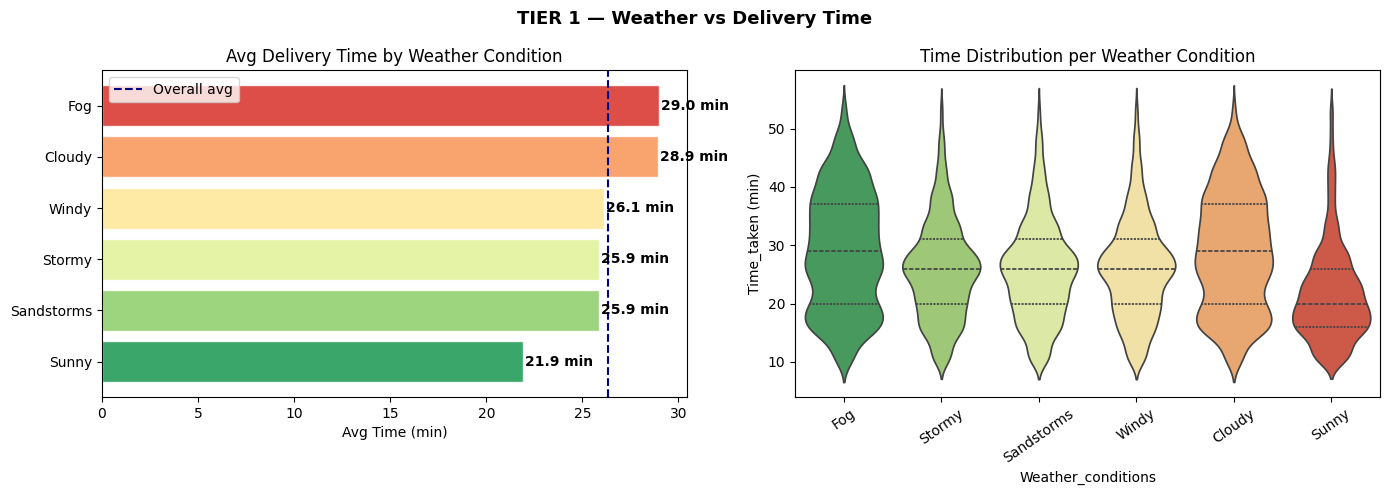

In [201]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

weather_means = df.groupby('Weather_conditions')['Time_taken (min)'].mean().sort_values(ascending=True)

# Horizontal bar chart
colors = plt.cm.RdYlGn_r(np.linspace(0.1, 0.9, len(weather_means)))
axes[0].barh(weather_means.index, weather_means.values, color=colors, alpha=0.85, edgecolor='white')
for i, v in enumerate(weather_means.values):
    axes[0].text(v+0.1, i, f'{v:.1f} min', va='center', fontweight='bold')
axes[0].set_title('Avg Delivery Time by Weather Condition')
axes[0].set_xlabel('Avg Time (min)')
axes[0].axvline(df['Time_taken (min)'].mean(), color='navy', linestyle='--', label='Overall avg')
axes[0].legend()

# Violin plot
sns.violinplot(x='Weather_conditions', y='Time_taken (min)', data=df,
               ax=axes[1], palette='RdYlGn_r', inner='quartile')
axes[1].set_title('Time Distribution per Weather Condition')
axes[1].tick_params(axis='x', rotation=35)

plt.suptitle('TIER 1 — Weather vs Delivery Time', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('T1_weather_vs_time.png', dpi=150, bbox_inches='tight')
plt.show()

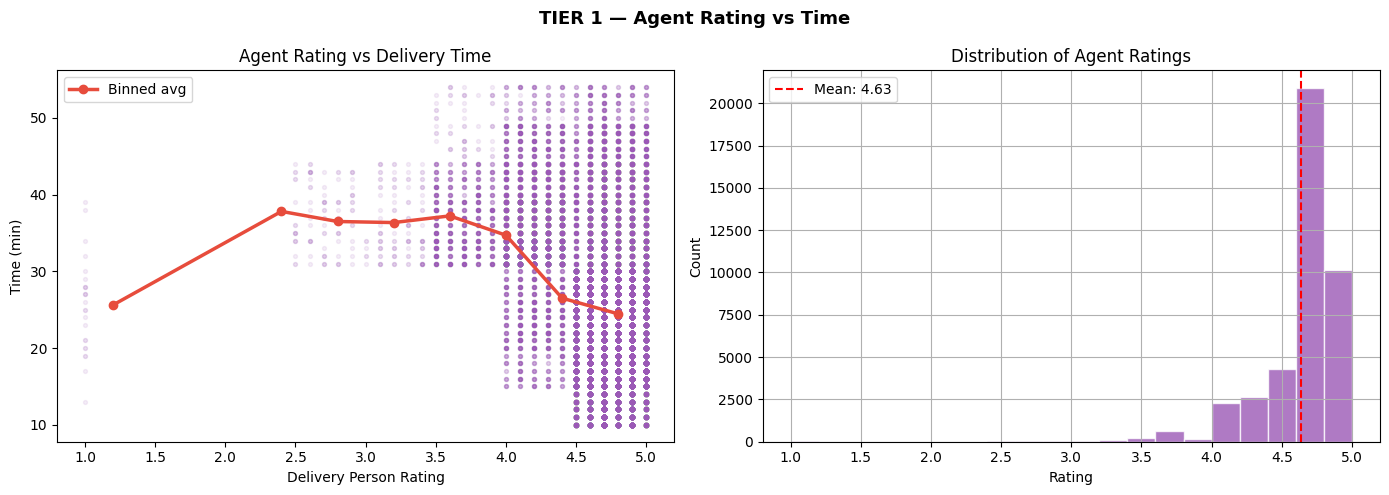

In [202]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter
axes[0].scatter(df['Delivery_person_Ratings'], df['Time_taken (min)'],
                alpha=0.1, color='#9B59B6', s=8)
rating_bins = df.groupby(pd.cut(df['Delivery_person_Ratings'],
                                 bins=10))['Time_taken (min)'].mean()
mid_points = [interval.mid for interval in rating_bins.index]
axes[0].plot(mid_points, rating_bins.values, color='#E74C3C',
             linewidth=2.5, marker='o', markersize=6, label='Binned avg')
axes[0].set_title('Agent Rating vs Delivery Time')
axes[0].set_xlabel('Delivery Person Rating')
axes[0].set_ylabel('Time (min)')
axes[0].legend()

# Distribution of ratings
df['Delivery_person_Ratings'].hist(bins=20, ax=axes[1], color='#9B59B6',
                                    alpha=0.8, edgecolor='white')
axes[1].axvline(df['Delivery_person_Ratings'].mean(), color='red',
                linestyle='--', label=f"Mean: {df['Delivery_person_Ratings'].mean():.2f}")
axes[1].set_title('Distribution of Agent Ratings')
axes[1].set_xlabel('Rating')
axes[1].set_ylabel('Count')
axes[1].legend()

plt.suptitle('TIER 1 — Agent Rating vs Time', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('T1_rating_vs_time.png', dpi=150, bbox_inches='tight')
plt.show()

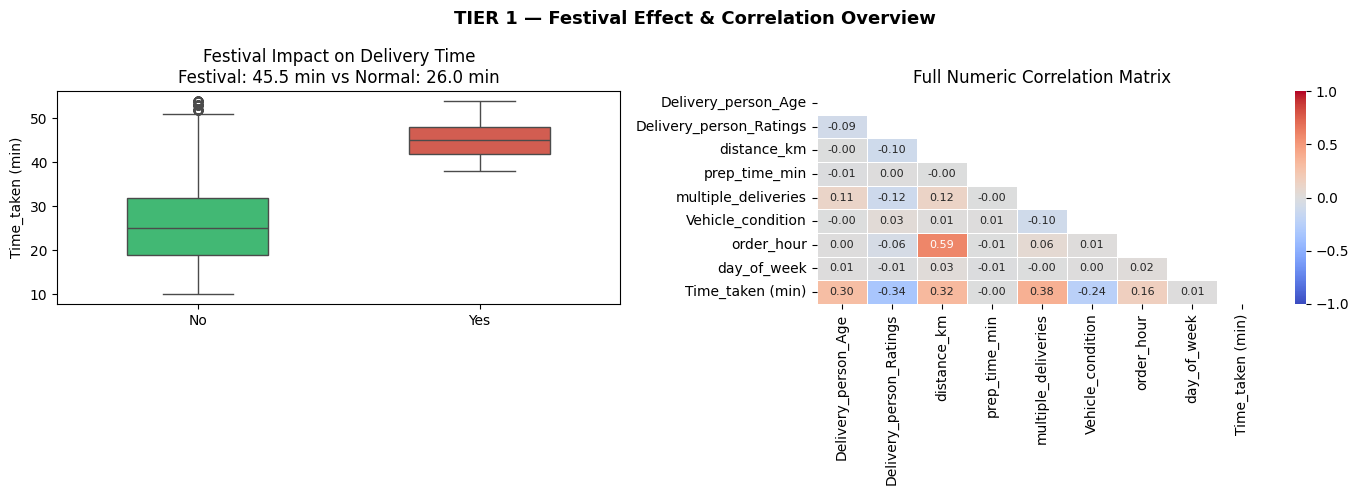


Top correlations with Time_taken (min):
multiple_deliveries        0.378376
distance_km                0.321082
Delivery_person_Age        0.295267
order_hour                 0.161084
day_of_week                0.005124
prep_time_min             -0.001818
Vehicle_condition         -0.237368
Delivery_person_Ratings   -0.340671


In [203]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Festival box
sns.boxplot(x='Festival', y='Time_taken (min)', data=df,
            ax=axes[0], palette={'Yes':'#E74C3C','No':'#2ECC71'}, width=0.5)
fest_yes = df[df['Festival']=='Yes']['Time_taken (min)'].mean()
fest_no  = df[df['Festival']=='No']['Time_taken (min)'].mean()
axes[0].set_title(f'Festival Impact on Delivery Time\nFestival: {fest_yes:.1f} min vs Normal: {fest_no:.1f} min')
axes[0].set_xlabel('')

# Numeric correlation heatmap
num_cols = ['Delivery_person_Age','Delivery_person_Ratings','distance_km',
            'prep_time_min','multiple_deliveries','Vehicle_condition',
            'order_hour','day_of_week','Time_taken (min)']
corr = df[num_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            ax=axes[1], linewidths=0.5, vmin=-1, vmax=1,
            annot_kws={'size':8})
axes[1].set_title('Full Numeric Correlation Matrix')

plt.suptitle('TIER 1 — Festival Effect & Correlation Overview', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('T1_festival_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nTop correlations with Time_taken (min):")
print(corr['Time_taken (min)'].sort_values(ascending=False).drop('Time_taken (min)').to_string())

tier 2

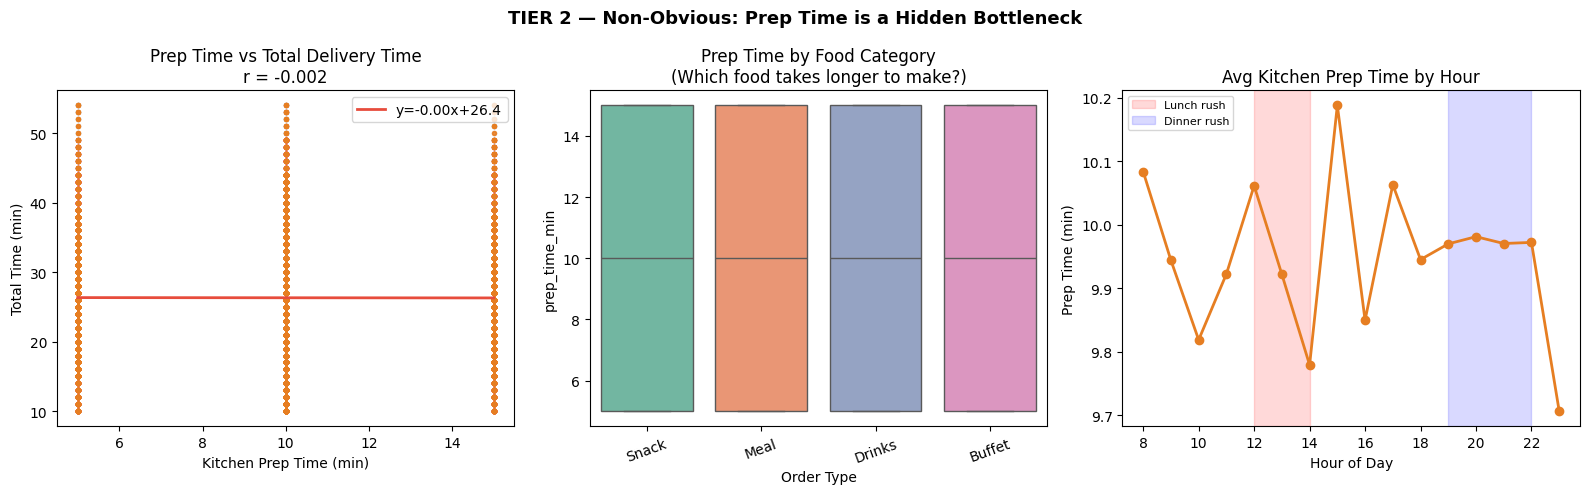

In [204]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr # Moved import here to ensure it's available

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('TIER 2 — Non-Obvious: Prep Time is a Hidden Bottleneck', fontsize=13, fontweight='bold')

# Prep time vs total time
valid_prep_time_data = df[df['prep_time_min'].notna() & df['Time_taken (min)'].notna()]

if len(valid_prep_time_data) >= 2:
    # Ensure values are within reasonable bounds for plotting and calculation
    clipped_prep_time = valid_prep_time_data['prep_time_min'].clip(0,60)

    axes[0].scatter(clipped_prep_time,
                    valid_prep_time_data['Time_taken (min)'], alpha=0.15, color='#E67E22', s=8)

    r2, _ = pearsonr(clipped_prep_time, valid_prep_time_data['Time_taken (min)'])
    axes[0].set_title(f'Prep Time vs Total Delivery Time\nr = {r2:.3f}')

    # Linear regression line
    m, b = np.polyfit(clipped_prep_time, valid_prep_time_data['Time_taken (min)'], 1)
    x_line = np.linspace(clipped_prep_time.min(), clipped_prep_time.max(), 100)
    axes[0].plot(x_line, m*x_line + b, color='#E74C3C', linewidth=2, label=f'y={m:.2f}x+{b:.1f}')
    axes[0].legend()
    axes[0].set_xlabel('Kitchen Prep Time (min)')
    axes[0].set_ylabel('Total Time (min)')
else:
    axes[0].set_title('Prep Time vs Total Delivery Time\n(Insufficient or invalid data for correlation)')
    axes[0].text(0.5, 0.5, 'No valid prep time data to plot', horizontalalignment='center', verticalalignment='center', transform=axes[0].transAxes)
    axes[0].set_xlabel('Kitchen Prep Time (min)')
    axes[0].set_ylabel('Total Time (min)')


# Prep time by order type
# Filter data for the plot, ensuring prep_time_min is valid
prep_time_for_boxplot = df[df['prep_time_min'].between(0,60)]
if not prep_time_for_boxplot.empty:
    sns.boxplot(x='Type_of_order', y='prep_time_min', data=prep_time_for_boxplot,
                ax=axes[1], palette='Set2')
    axes[1].set_title('Prep Time by Food Category\n(Which food takes longer to make?)')
    axes[1].set_xlabel('Order Type')
    axes[1].tick_params(axis='x', rotation=20)
else:
    axes[1].set_title('Prep Time by Food Category\n(No valid prep time data)')
    axes[1].text(0.5, 0.5, 'No valid prep time data to plot', horizontalalignment='center', verticalalignment='center', transform=axes[1].transAxes)
    axes[1].set_xlabel('Order Type')


# Prep time by hour — kitchen rush
# Filter data for the plot, ensuring prep_time_min is valid
prep_time_for_hourly = df[df['prep_time_min'].between(0,60)]
if not prep_time_for_hourly.empty:
    prep_hourly = prep_time_for_hourly.groupby('order_hour')['prep_time_min'].mean()
    if not prep_hourly.empty: # Check if groupby resulted in anything
        axes[2].plot(prep_hourly.index, prep_hourly.values, marker='o', color='#E67E22', linewidth=2)
        axes[2].axvspan(12,14,alpha=0.15,color='red',label='Lunch rush')
        axes[2].axvspan(19,22,alpha=0.15,color='blue',label='Dinner rush')
        axes[2].set_title('Avg Kitchen Prep Time by Hour')
        axes[2].set_xlabel('Hour of Day')
        axes[2].set_ylabel('Prep Time (min)')
        axes[2].legend(fontsize=8)
    else:
        axes[2].set_title('Avg Kitchen Prep Time by Hour\n(No valid prep time data)')
        axes[2].text(0.5, 0.5, 'No valid prep time data to plot', horizontalalignment='center', verticalalignment='center', transform=axes[2].transAxes)
        axes[2].set_xlabel('Hour of Day')
        axes[2].set_ylabel('Prep Time (min)')
else:
    axes[2].set_title('Avg Kitchen Prep Time by Hour\n(No valid prep time data)')
    axes[2].text(0.5, 0.5, 'No valid prep time data to plot', horizontalalignment='center', verticalalignment='center', transform=axes[2].transAxes)
    axes[2].set_xlabel('Hour of Day')
    axes[2].set_ylabel('Prep Time (min)')


plt.tight_layout()
plt.savefig('T2_prep_time_bottleneck.png', dpi=150, bbox_inches='tight')
plt.show()

new stuff


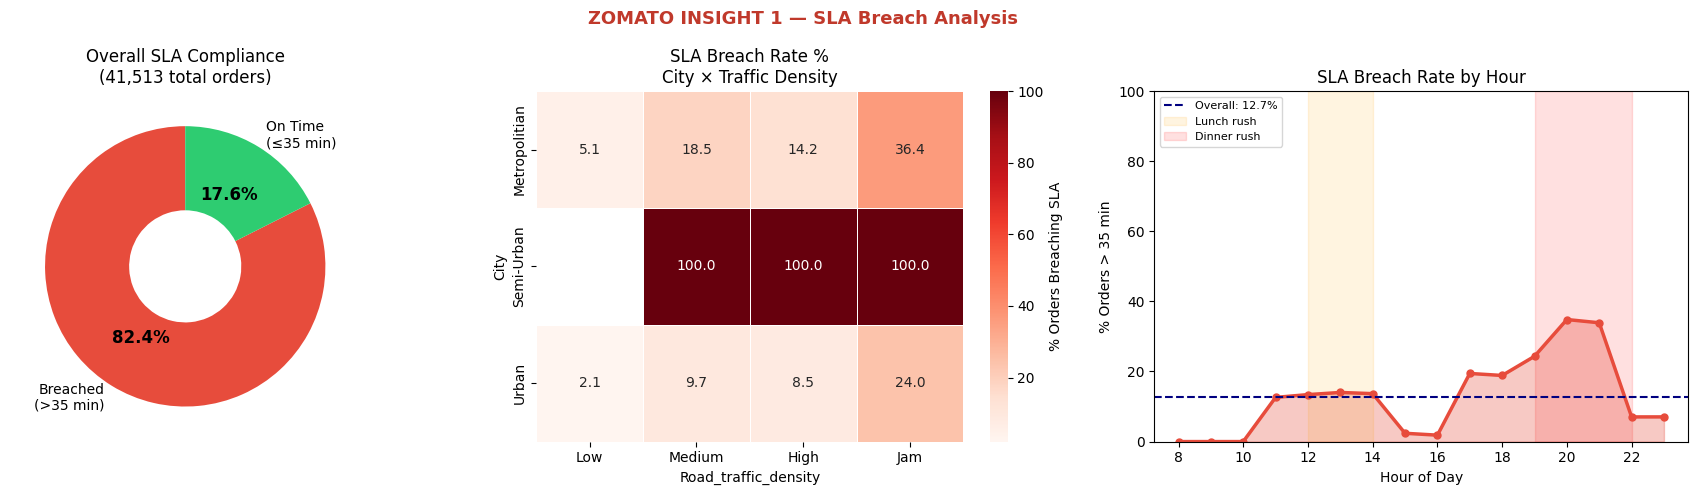

Overall breach rate: 17.6%
Worst combo: ('Semi-Urban', 'Medium') → 100.0%
Peak breach hour: 20.0:00 → 34.8%


In [205]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('ZOMATO INSIGHT 1 — SLA Breach Analysis', fontsize=13, fontweight='bold', color='#C0392B')

df['sla_breach'] = (df['Time_taken (min)'] > 35).astype(int)

# Panel 1: Overall breach donut
breach_counts = df['sla_breach'].value_counts()
colors_b = ['#E74C3C', '#2ECC71']
wedges, texts, autotexts = axes[0].pie(
    breach_counts.values,
    labels=['Breached\n(>35 min)', 'On Time\n(≤35 min)'],
    autopct='%1.1f%%', colors=colors_b,
    startangle=90, wedgeprops={'width': 0.6}
)
for at in autotexts:
    at.set_fontweight('bold')
    at.set_fontsize(12)
axes[0].set_title(f'Overall SLA Compliance\n({len(df):,} total orders)')

# Panel 2: Breach rate by City × Traffic heatmap
breach_map = df.groupby(['City', 'Road_traffic_density'])['sla_breach'].mean().unstack() * 100
traffic_cols = [c for c in ['Low', 'Medium', 'High', 'Jam'] if c in breach_map.columns]
breach_map = breach_map[traffic_cols]
sns.heatmap(breach_map, annot=True, fmt='.1f', cmap='Reds',
            ax=axes[1], linewidths=0.5,
            cbar_kws={'label': '% Orders Breaching SLA'})
axes[1].set_title('SLA Breach Rate %\nCity × Traffic Density')

# Panel 3: Breach rate by hour
hourly_breach = df.groupby('order_hour')['sla_breach'].mean() * 100
axes[2].fill_between(hourly_breach.index, hourly_breach.values, alpha=0.3, color='#E74C3C')
axes[2].plot(hourly_breach.index, hourly_breach.values,
             color='#E74C3C', linewidth=2.5, marker='o', markersize=5)
axes[2].axhline(hourly_breach.mean(), color='navy', linestyle='--',
                label=f'Overall: {hourly_breach.mean():.1f}%')
axes[2].axvspan(12, 14, alpha=0.12, color='orange', label='Lunch rush')
axes[2].axvspan(19, 22, alpha=0.12, color='red', label='Dinner rush')
axes[2].set_title('SLA Breach Rate by Hour')
axes[2].set_xlabel('Hour of Day')
axes[2].set_ylabel('% Orders > 35 min')
axes[2].legend(fontsize=8)
axes[2].set_ylim(0, 100)

plt.tight_layout()
plt.savefig('Z1_sla_breach.png', dpi=150, bbox_inches='tight')
plt.show()

overall = df['sla_breach'].mean() * 100
print(f"Overall breach rate: {overall:.1f}%")
print(f"Worst combo: {breach_map.stack().idxmax()} → {breach_map.stack().max():.1f}%")
print(f"Peak breach hour: {hourly_breach.idxmax()}:00 → {hourly_breach.max():.1f}%")

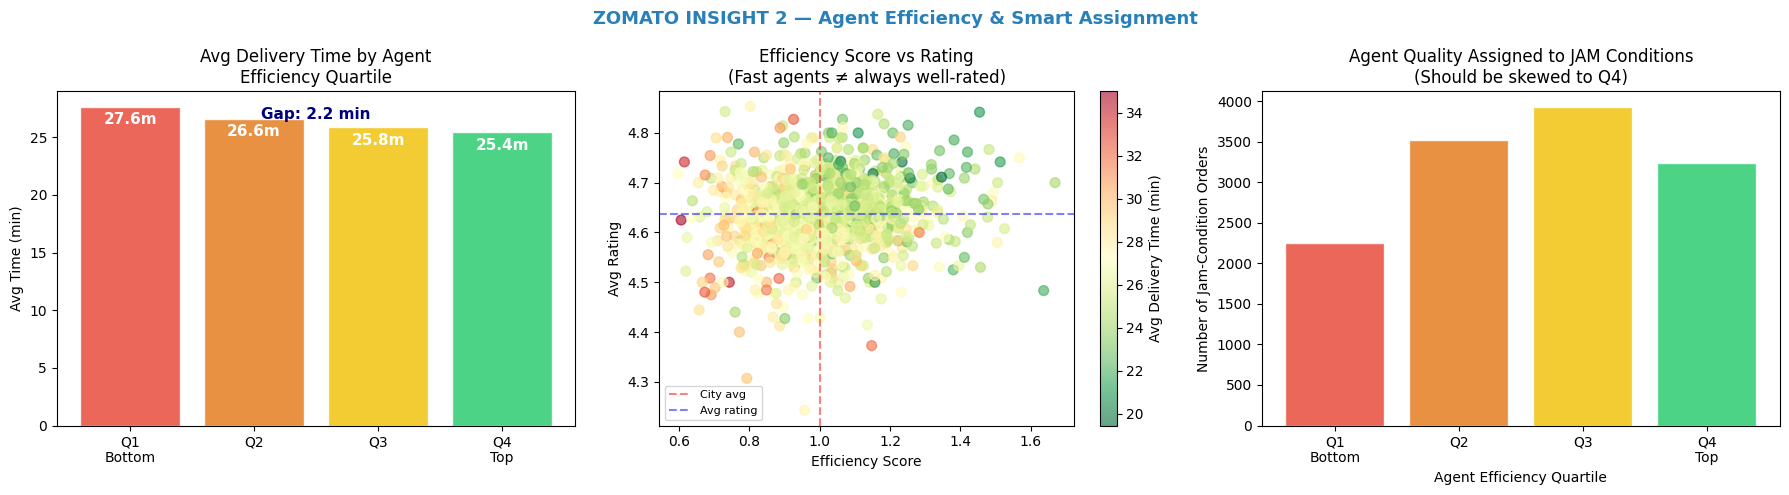

Q1 avg time: 27.6 min | Q4 avg time: 25.4 min
Potential time saving with smart assignment: 2.2 min/order


In [206]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('ZOMATO INSIGHT 2 — Agent Efficiency & Smart Assignment', fontsize=13, fontweight='bold', color='#2980B9')

df['speed_kmpm'] = df['distance_km'] / df['Time_taken (min)'].replace(0, np.nan)
df['city_avg_speed'] = df.groupby('City')['speed_kmpm'].transform('mean')
df['efficiency_score'] = df['speed_kmpm'] / df['city_avg_speed']

agent_stats = df.groupby('Delivery_person_ID').agg(
    avg_efficiency = ('efficiency_score', 'mean'),
    avg_rating     = ('Delivery_person_Ratings', 'mean'),
    avg_time       = ('Time_taken (min)', 'mean'),
    total_orders   = ('Time_taken (min)', 'count')
).reset_index().dropna()

# Panel 1: Efficiency distribution
agent_stats['quartile'] = pd.qcut(agent_stats['avg_efficiency'],
                                   q=4, labels=['Q1\nBottom', 'Q2', 'Q3', 'Q4\nTop'])
q_time = agent_stats.groupby('quartile')['avg_time'].mean()
colors_q = ['#E74C3C', '#E67E22', '#F1C40F', '#2ECC71']
bars = axes[0].bar(q_time.index, q_time.values, color=colors_q, alpha=0.85, edgecolor='white')
for bar, val in zip(bars, q_time.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() - 1.5,
                 f'{val:.1f}m', ha='center', color='white', fontweight='bold', fontsize=11)
axes[0].set_title('Avg Delivery Time by Agent\nEfficiency Quartile')
axes[0].set_ylabel('Avg Time (min)')
savings = q_time['Q1\nBottom'] - q_time['Q4\nTop']
axes[0].text(1.5, q_time.max() - 1, f'Gap: {savings:.1f} min', ha='center',
             color='navy', fontweight='bold', fontsize=11)

# Panel 2: Efficiency vs Rating scatter
sc = axes[1].scatter(agent_stats['avg_efficiency'],
                      agent_stats['avg_rating'],
                      c=agent_stats['avg_time'], cmap='RdYlGn_r',
                      alpha=0.6, s=50)
plt.colorbar(sc, ax=axes[1], label='Avg Delivery Time (min)')
axes[1].axvline(1.0, color='red', linestyle='--', alpha=0.5, label='City avg')
axes[1].axhline(agent_stats['avg_rating'].mean(), color='blue',
                linestyle='--', alpha=0.5, label='Avg rating')
axes[1].set_title('Efficiency Score vs Rating\n(Fast agents ≠ always well-rated)')
axes[1].set_xlabel('Efficiency Score')
axes[1].set_ylabel('Avg Rating')
axes[1].legend(fontsize=8)

# Panel 3: Are elite agents assigned during worst conditions?
df['agent_quartile'] = df['Delivery_person_ID'].map(
    agent_stats.set_index('Delivery_person_ID')['quartile'])
cond_assignment = df[df['Road_traffic_density'] == 'Jam'].groupby(
    'agent_quartile')['Time_taken (min)'].count()
cond_assignment = cond_assignment.reindex(['Q1\nBottom', 'Q2', 'Q3', 'Q4\nTop'])
axes[2].bar(cond_assignment.index, cond_assignment.values,
            color=colors_q, alpha=0.85, edgecolor='white')
axes[2].set_title('Agent Quality Assigned to JAM Conditions\n(Should be skewed to Q4)')
axes[2].set_xlabel('Agent Efficiency Quartile')
axes[2].set_ylabel('Number of Jam-Condition Orders')

plt.tight_layout()
plt.savefig('Z2_agent_efficiency.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Q1 avg time: {q_time['Q1\nBottom']:.1f} min | Q4 avg time: {q_time['Q4\nTop']:.1f} min")
print(f"Potential time saving with smart assignment: {savings:.1f} min/order")

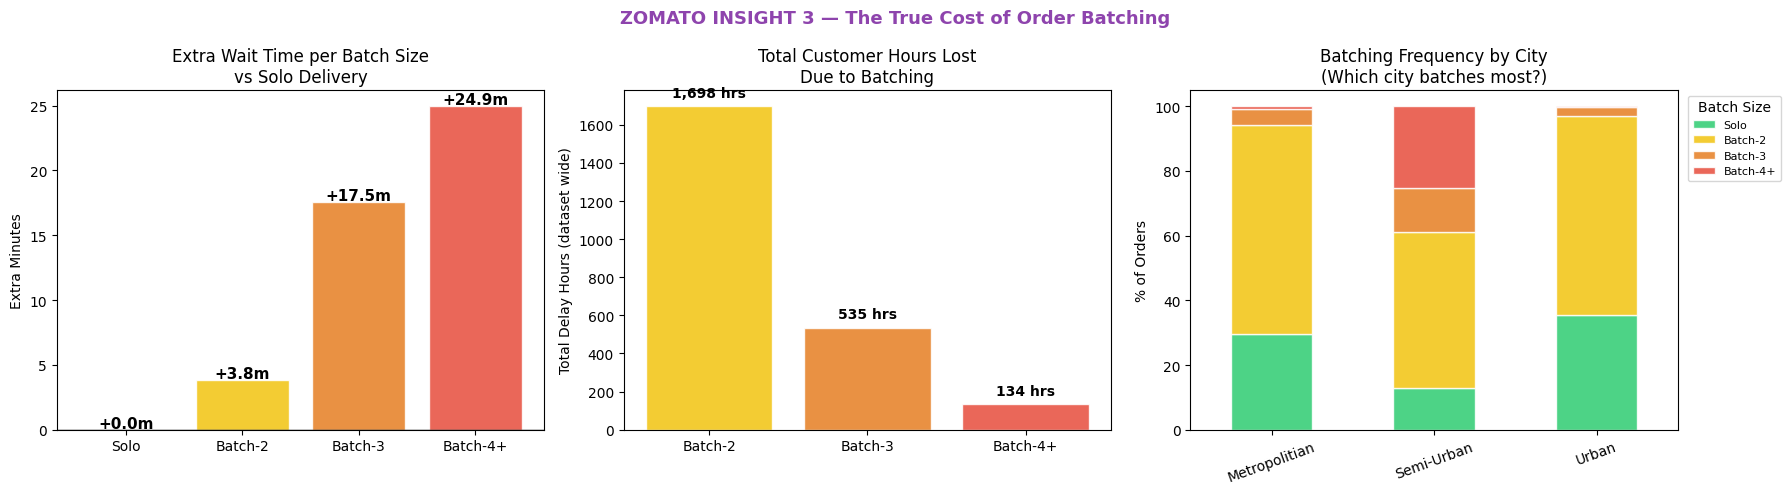

Batching penalty summary:
           mean  penalty  count  total_delay_hours
md_label                                          
Solo      22.89     0.00  12825               0.00
Batch-2   26.73     3.84  26536            1697.60
Batch-3   40.44    17.55   1829             534.83
Batch-4+  47.84    24.95    323             134.30


In [207]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('ZOMATO INSIGHT 3 — The True Cost of Order Batching', fontsize=13, fontweight='bold', color='#8E44AD')

df['multiple_deliveries'] = df['multiple_deliveries'].fillna(0).astype(int)
md_labels = {0: 'Solo', 1: 'Batch-2', 2: 'Batch-3', 3: 'Batch-4+'}
df['md_label'] = df['multiple_deliveries'].map(md_labels)
md_order = ['Solo', 'Batch-2', 'Batch-3', 'Batch-4+']

md_stats = df.groupby('md_label')['Time_taken (min)'].agg(['mean', 'std', 'count']).reindex(md_order)
base = md_stats.loc['Solo', 'mean']
md_stats['penalty'] = md_stats['mean'] - base
md_stats['total_delay_hours'] = (md_stats['penalty'] * md_stats['count']) / 60

# Panel 1: Time penalty per batch size
colors_md = ['#2ECC71', '#F1C40F', '#E67E22', '#E74C3C']
bars = axes[0].bar(md_order, md_stats['penalty'].values,
                   color=colors_md, alpha=0.85, edgecolor='white')
axes[0].axhline(0, color='black', linewidth=1)
for bar, val in zip(bars, md_stats['penalty'].values):
    label = f'+{val:.1f}m' if val >= 0 else f'{val:.1f}m'
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.15 if val >= 0 else bar.get_height() - 0.6,
                 label, ha='center', fontweight='bold', fontsize=11)
axes[0].set_title('Extra Wait Time per Batch Size\nvs Solo Delivery')
axes[0].set_ylabel('Extra Minutes')

# Panel 2: Total cumulative delay hours caused
axes[1].bar(md_order[1:], md_stats['total_delay_hours'].values[1:],
            color=colors_md[1:], alpha=0.85, edgecolor='white')
axes[1].set_title('Total Customer Hours Lost\nDue to Batching')
axes[1].set_ylabel('Total Delay Hours (dataset wide)')
for i, val in enumerate(md_stats['total_delay_hours'].values[1:]):
    axes[1].text(i, val + 50, f'{val:,.0f} hrs', ha='center', fontweight='bold')

# Panel 3: Batch size distribution by city
batch_city = df.groupby(['City', 'md_label']).size().unstack(fill_value=0).reindex(columns=md_order)
batch_city_pct = batch_city.div(batch_city.sum(axis=1), axis=0) * 100
batch_city_pct.plot(kind='bar', stacked=True, ax=axes[2],
                    color=colors_md, alpha=0.85, edgecolor='white')
axes[2].set_title('Batching Frequency by City\n(Which city batches most?)')
axes[2].set_xlabel('')
axes[2].set_ylabel('% of Orders')
axes[2].tick_params(axis='x', rotation=20)
axes[2].legend(title='Batch Size', bbox_to_anchor=(1.01, 1), fontsize=8)

plt.tight_layout()
plt.savefig('Z3_batching_cost.png', dpi=150, bbox_inches='tight')
plt.show()

print("Batching penalty summary:")
print(md_stats[['mean', 'penalty', 'count', 'total_delay_hours']].round(2).to_string())

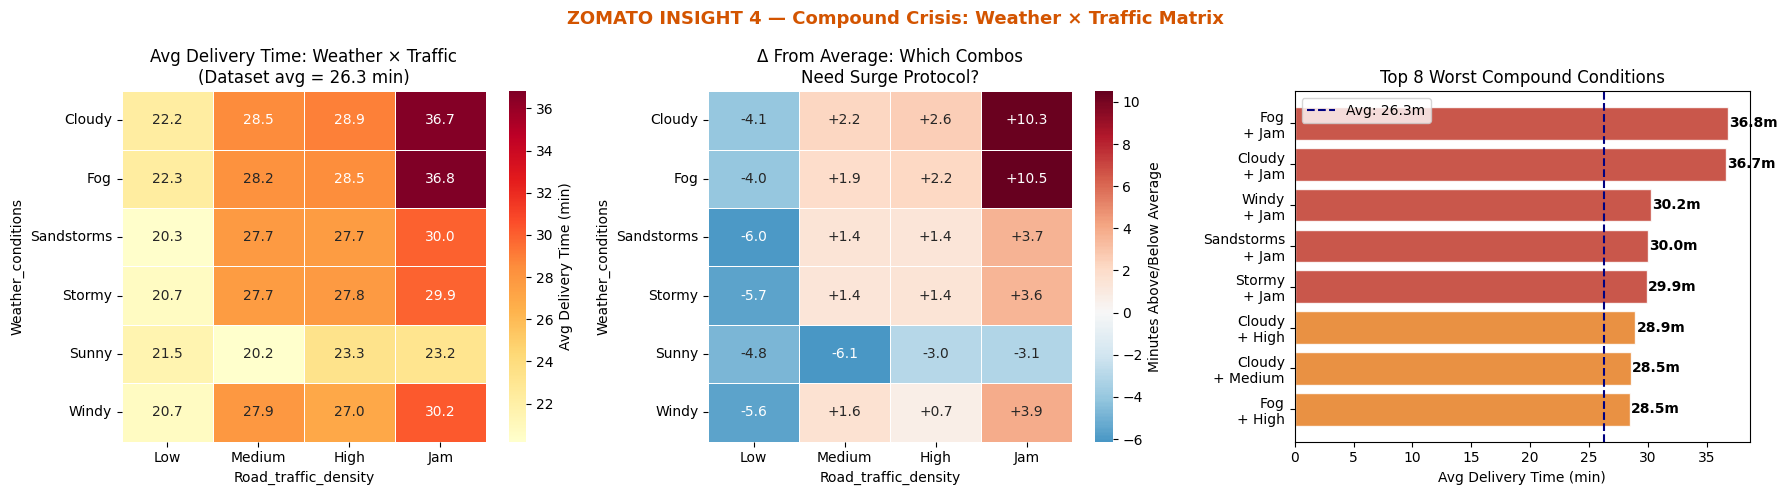

Worst compound condition: ('Fog', 'Jam') → 36.8 min
That's +10.5 min above average


In [208]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('ZOMATO INSIGHT 4 — Compound Crisis: Weather × Traffic Matrix', fontsize=13, fontweight='bold', color='#D35400')

# Panel 1: Heatmap of avg time
pivot = df.groupby(['Weather_conditions', 'Road_traffic_density'])['Time_taken (min)'].mean().unstack()
traffic_cols = [c for c in ['Low', 'Medium', 'High', 'Jam'] if c in pivot.columns]
pivot = pivot[traffic_cols]
overall_avg = df['Time_taken (min)'].mean()

sns.heatmap(pivot, annot=True, fmt='.1f', cmap='YlOrRd',
            ax=axes[0], linewidths=0.5,
            cbar_kws={'label': 'Avg Delivery Time (min)'})
axes[0].set_title(f'Avg Delivery Time: Weather × Traffic\n(Dataset avg = {overall_avg:.1f} min)')

# Panel 2: Delta from average — how much above normal
delta_pivot = pivot - overall_avg
sns.heatmap(delta_pivot, annot=True, fmt='+.1f', cmap='RdBu_r',
            center=0, ax=axes[1], linewidths=0.5,
            cbar_kws={'label': 'Minutes Above/Below Average'})
axes[1].set_title('Δ From Average: Which Combos\nNeed Surge Protocol?')

# Panel 3: Worst 8 compound conditions ranked
combo_avg = df.groupby(['Weather_conditions', 'Road_traffic_density'])['Time_taken (min)'].mean()
combo_avg.name = 'avg_time'
combo_df = combo_avg.reset_index()
combo_df['label'] = combo_df['Weather_conditions'] + '\n+ ' + combo_df['Road_traffic_density']
combo_df['delta'] = combo_df['avg_time'] - overall_avg
top8 = combo_df.nlargest(8, 'avg_time')

colors_c = ['#C0392B' if d > 3 else '#E67E22' if d > 1 else '#F1C40F'
            for d in top8['delta']]
axes[2].barh(top8['label'][::-1], top8['avg_time'][::-1],
             color=colors_c[::-1], alpha=0.85, edgecolor='white')
axes[2].axvline(overall_avg, color='navy', linestyle='--', label=f'Avg: {overall_avg:.1f}m')
axes[2].set_title('Top 8 Worst Compound Conditions')
axes[2].set_xlabel('Avg Delivery Time (min)')
axes[2].legend()
for i, (_, row) in enumerate(top8[::-1].iterrows()):
    axes[2].text(row['avg_time'] + 0.1, i, f"{row['avg_time']:.1f}m", va='center', fontweight='bold')

plt.tight_layout()
plt.savefig('Z4_compound_crisis.png', dpi=150, bbox_inches='tight')
plt.show()

worst = combo_avg.idxmax()
print(f"Worst compound condition: {worst} → {combo_avg.max():.1f} min")
print(f"That's +{combo_avg.max() - overall_avg:.1f} min above average")

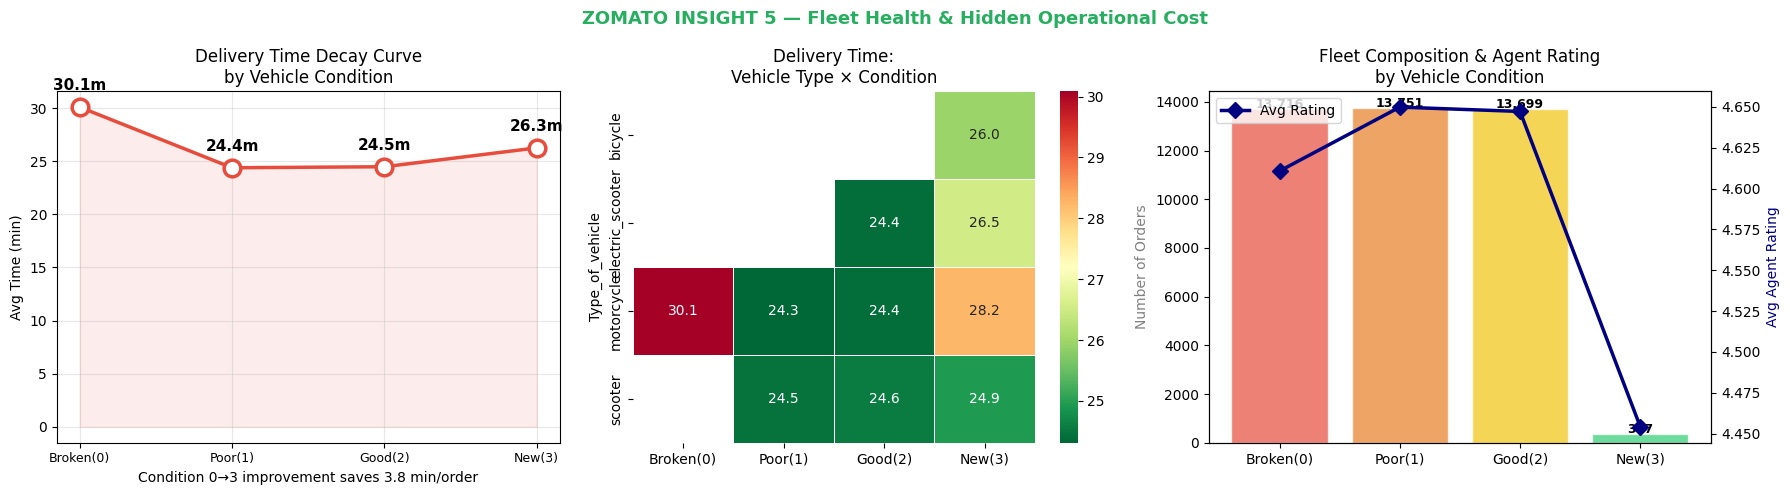

Vehicle condition summary:
  Broken(0): 30.1 min avg | 4.61 rating | 13,716 orders (33.0%)
  Poor(1): 24.4 min avg | 4.65 rating | 13,751 orders (33.1%)
  Good(2): 24.5 min avg | 4.65 rating | 13,699 orders (33.0%)
  New(3): 26.3 min avg | 4.45 rating | 347 orders (0.8%)


In [209]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('ZOMATO INSIGHT 5 — Fleet Health & Hidden Operational Cost', fontsize=13, fontweight='bold', color='#27AE60')

vc_labels = {0: 'Broken(0)', 1: 'Poor(1)', 2: 'Good(2)', 3: 'New(3)'}
vc_colors = ['#E74C3C', '#E67E22', '#F1C40F', '#2ECC71']
df['vc_label'] = df['Vehicle_condition'].map(vc_labels)
vc_order = ['Broken(0)', 'Poor(1)', 'Good(2)', 'New(3)']

# Panel 1: Delivery time decay curve
vc_time = df.groupby('vc_label')['Time_taken (min)'].mean().reindex(vc_order)
axes[0].plot(range(4), vc_time.values, marker='o', color='#E74C3C',
             linewidth=2.5, markersize=12, markerfacecolor='white', markeredgewidth=2.5)
axes[0].fill_between(range(4), vc_time.values, alpha=0.1, color='#E74C3C')
for i, (label, val) in enumerate(vc_time.items()):
    axes[0].annotate(f'{val:.1f}m', (i, val),
                     textcoords='offset points', xytext=(0, 12),
                     ha='center', fontweight='bold', fontsize=11)
axes[0].set_xticks(range(4))
axes[0].set_xticklabels(vc_order, fontsize=9)
axes[0].set_title('Delivery Time Decay Curve\nby Vehicle Condition')
axes[0].set_ylabel('Avg Time (min)')
axes[0].grid(alpha=0.3)
decay = vc_time['Broken(0)'] - vc_time['New(3)']
axes[0].set_xlabel(f'Condition 0→3 improvement saves {decay:.1f} min/order')

# Panel 2: Vehicle type × condition heatmap
vc_type = df.groupby(['Type_of_vehicle', 'Vehicle_condition'])['Time_taken (min)'].mean().unstack()
vc_type.columns = [vc_labels[c] for c in vc_type.columns]
vc_type = vc_type[vc_order]
sns.heatmap(vc_type, annot=True, fmt='.1f', cmap='RdYlGn_r',
            ax=axes[1], linewidths=0.5)
axes[1].set_title('Delivery Time:\nVehicle Type × Condition')

# Panel 3: Fleet composition + rating impact
fleet_share = df['vc_label'].value_counts().reindex(vc_order)
vc_rating   = df.groupby('vc_label')['Delivery_person_Ratings'].mean().reindex(vc_order)

ax2 = axes[2].twinx()
bars = axes[2].bar(vc_order, fleet_share.values, color=vc_colors, alpha=0.7, edgecolor='white')
ax2.plot(vc_order, vc_rating.values, color='navy', marker='D',
         linewidth=2.5, markersize=8, label='Avg Rating')
axes[2].set_title('Fleet Composition & Agent Rating\nby Vehicle Condition')
axes[2].set_ylabel('Number of Orders', color='grey')
ax2.set_ylabel('Avg Agent Rating', color='navy')
ax2.legend(loc='upper left')
for bar, val in zip(bars, fleet_share.values):
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
                 f'{val:,}', ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('Z5_fleet_health.png', dpi=150, bbox_inches='tight')
plt.show()

print("Vehicle condition summary:")
for vc in vc_order:
    t = vc_time[vc]
    r = vc_rating[vc]
    n = fleet_share[vc]
    print(f"  {vc}: {t:.1f} min avg | {r:.2f} rating | {n:,} orders ({n/len(df)*100:.1f}%)")

for restuarants

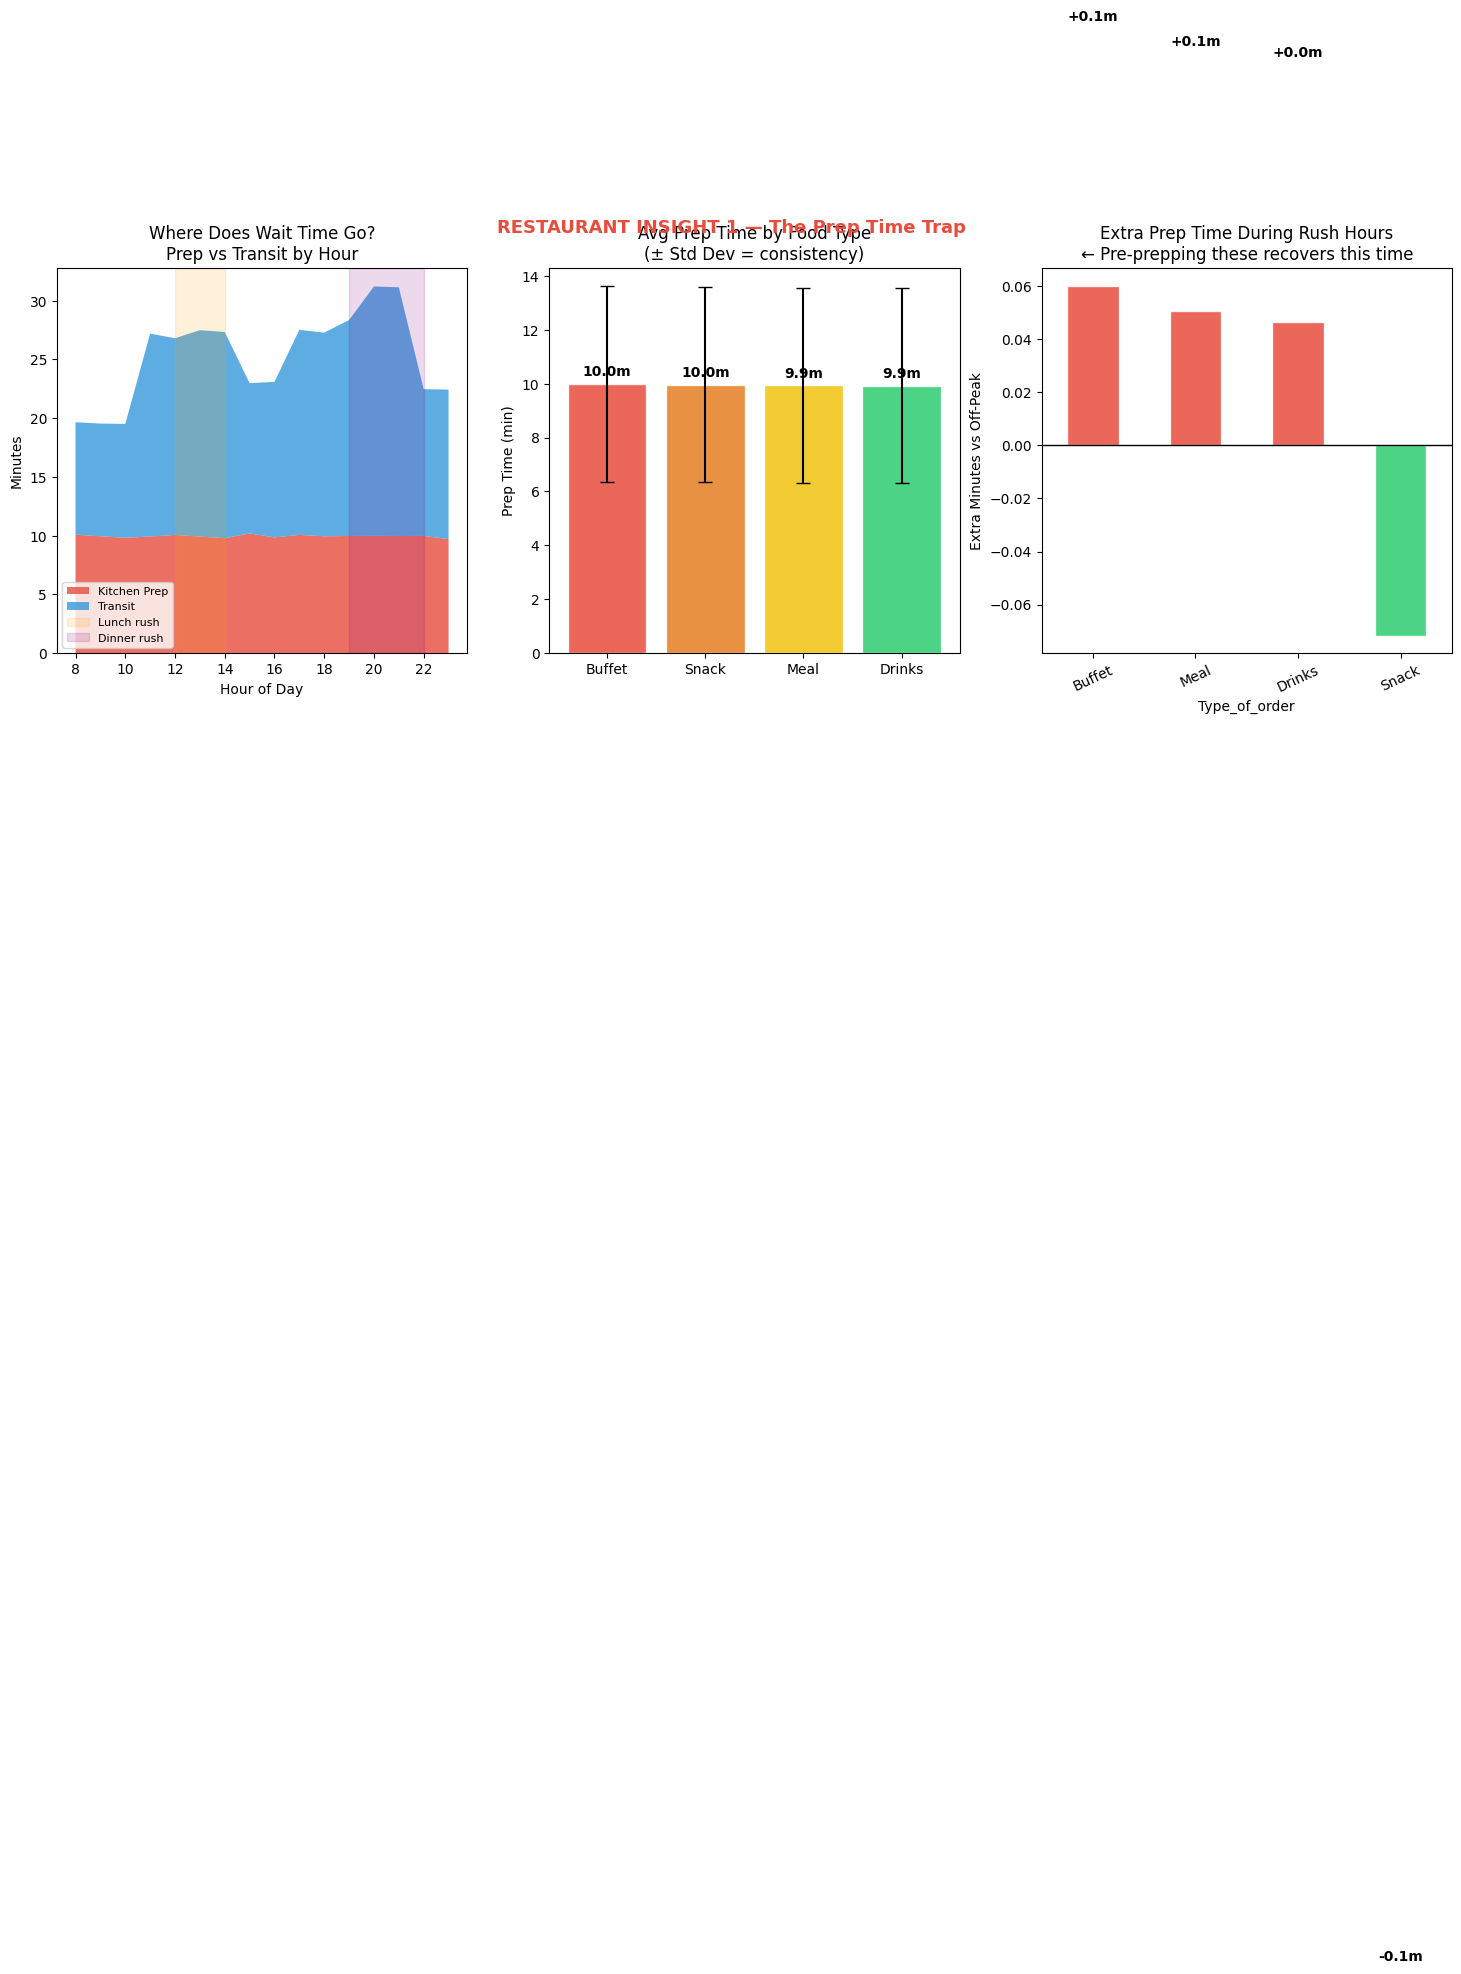

Peak hour prep surge:
  Buffet: +0.06 min extra during rush
  Meal: +0.05 min extra during rush
  Drinks: +0.05 min extra during rush
  Snack: +-0.07 min extra during rush


In [210]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('RESTAURANT INSIGHT 1 — The Prep Time Trap', fontsize=13, fontweight='bold', color='#E74C3C')

prep_clean = df[df['prep_time_min'].between(0, 60)].copy()

# Panel 1: Prep vs transit contribution by hour
hourly = prep_clean.groupby('order_hour').agg(
    avg_total  = ('Time_taken (min)', 'mean'),
    avg_prep   = ('prep_time_min', 'mean'),
    vol        = ('Time_taken (min)', 'count')
).reset_index()
hourly['transit'] = (hourly['avg_total'] - hourly['avg_prep']).clip(lower=0)
hourly['prep_capped'] = hourly['avg_prep'].clip(upper=hourly['avg_total'])

axes[0].stackplot(hourly['order_hour'],
                  hourly['prep_capped'], hourly['transit'],
                  labels=['Kitchen Prep', 'Transit'],
                  colors=['#E74C3C', '#3498DB'], alpha=0.8)
axes[0].axvspan(12, 14, alpha=0.15, color='orange', label='Lunch rush')
axes[0].axvspan(19, 22, alpha=0.15, color='purple', label='Dinner rush')
axes[0].set_title('Where Does Wait Time Go?\nPrep vs Transit by Hour')
axes[0].set_xlabel('Hour of Day')
axes[0].set_ylabel('Minutes')
axes[0].legend(fontsize=8)

# Panel 2: Prep time by food type — which takes longest
prep_food = prep_clean.groupby('Type_of_order')['prep_time_min'].agg(['mean', 'std']).sort_values('mean', ascending=False)
colors_food = ['#E74C3C', '#E67E22', '#F1C40F', '#2ECC71']
bars = axes[1].bar(prep_food.index, prep_food['mean'],
                   yerr=prep_food['std'], capsize=5,
                   color=colors_food, alpha=0.85, edgecolor='white')
axes[1].set_title('Avg Prep Time by Food Type\n(± Std Dev = consistency)')
axes[1].set_ylabel('Prep Time (min)')
for bar, val in zip(bars, prep_food['mean'].values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 f'{val:.1f}m', ha='center', fontweight='bold')

# Panel 3: Peak vs off-peak prep gap = pre-prep opportunity
off_peak = prep_clean[prep_clean['is_peak_hour'] == 0].groupby('Type_of_order')['prep_time_min'].mean()
peak     = prep_clean[prep_clean['is_peak_hour'] == 1].groupby('Type_of_order')['prep_time_min'].mean()
gap      = (peak - off_peak).sort_values(ascending=False)

colors_g = ['#E74C3C' if v > 0 else '#2ECC71' for v in gap.values]
gap.plot(kind='bar', ax=axes[2], color=colors_g, alpha=0.85, edgecolor='white')
axes[2].axhline(0, color='black', linewidth=1)
axes[2].set_title('Extra Prep Time During Rush Hours\n← Pre-prepping these recovers this time')
axes[2].set_ylabel('Extra Minutes vs Off-Peak')
axes[2].tick_params(axis='x', rotation=25)
for i, v in enumerate(gap.values):
    axes[2].text(i, v + 0.1 if v >= 0 else v - 0.5,
                 f'+{v:.1f}m' if v >= 0 else f'{v:.1f}m',
                 ha='center', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.savefig('R1_prep_trap.png', dpi=150, bbox_inches='tight')
plt.show()

print("Peak hour prep surge:")
for food in gap.index:
    print(f"  {food}: +{gap[food]:.2f} min extra during rush")

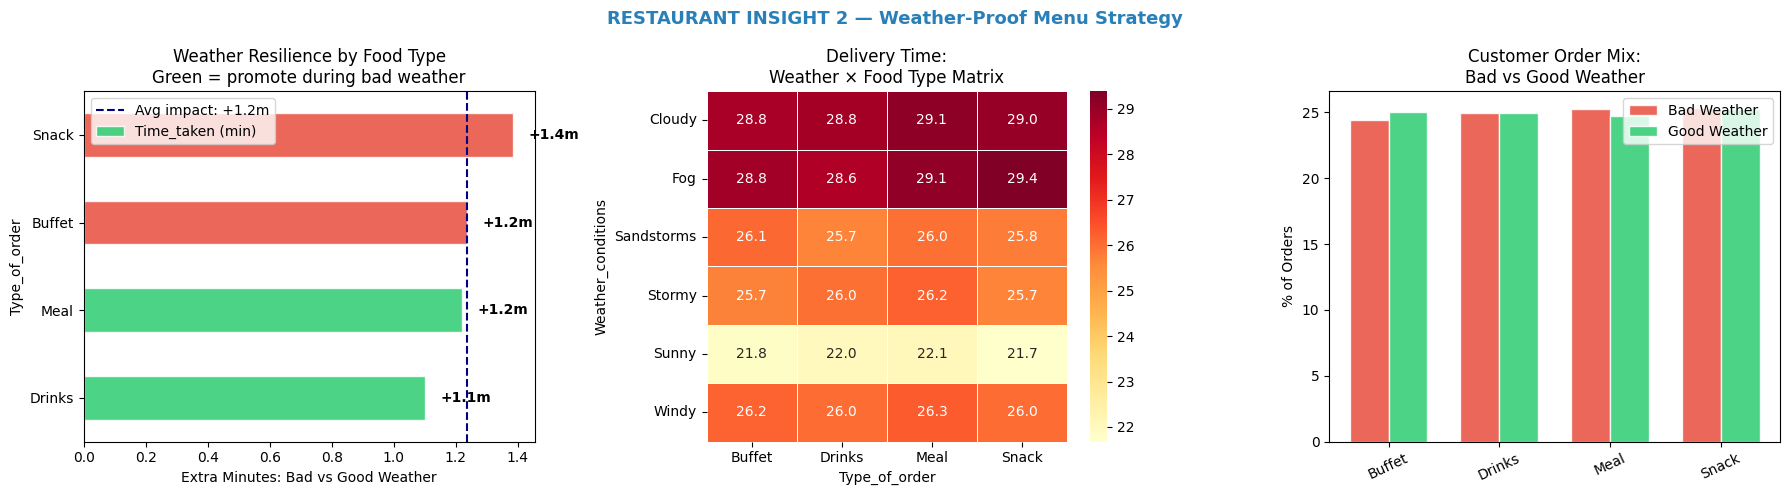

Weather resilience ranking (lower = promote more during bad weather):
Type_of_order
Drinks    1.10
Meal      1.22
Buffet    1.24
Snack     1.38


In [211]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('RESTAURANT INSIGHT 2 — Weather-Proof Menu Strategy', fontsize=13, fontweight='bold', color='#2980B9')

bad_weather  = [w for w in ['Stormy', 'Fog', 'Sandstorms']
                if w in df['Weather_conditions'].unique()]
good_weather = [w for w in ['Sunny', 'Windy', 'Cloudy']
                if w in df['Weather_conditions'].unique()]

bad_time  = df[df['Weather_conditions'].isin(bad_weather)].groupby('Type_of_order')['Time_taken (min)'].mean()
good_time = df[df['Weather_conditions'].isin(good_weather)].groupby('Type_of_order')['Time_taken (min)'].mean()
resilience = (bad_time - good_time).sort_values()

# Panel 1: Resilience ranking
colors_r = ['#2ECC71' if v <= resilience.mean() else '#E74C3C' for v in resilience.values]
resilience.plot(kind='barh', ax=axes[0], color=colors_r, alpha=0.85, edgecolor='white')
axes[0].axvline(resilience.mean(), color='navy', linestyle='--',
                label=f'Avg impact: +{resilience.mean():.1f}m')
axes[0].set_title('Weather Resilience by Food Type\nGreen = promote during bad weather')
axes[0].set_xlabel('Extra Minutes: Bad vs Good Weather')
axes[0].legend()
for i, v in enumerate(resilience.values):
    axes[0].text(v + 0.05, i, f'+{v:.1f}m', va='center', fontweight='bold')

# Panel 2: Full weather × food type matrix
weather_food = df.groupby(['Weather_conditions', 'Type_of_order'])['Time_taken (min)'].mean().unstack()
sns.heatmap(weather_food, annot=True, fmt='.1f', cmap='YlOrRd',
            ax=axes[1], linewidths=0.5)
axes[1].set_title('Delivery Time:\nWeather × Food Type Matrix')

# Panel 3: Order mix shift — do customers order differently in bad weather?
bad_mix  = df[df['Weather_conditions'].isin(bad_weather)]['Type_of_order'].value_counts(normalize=True) * 100
good_mix = df[df['Weather_conditions'].isin(good_weather)]['Type_of_order'].value_counts(normalize=True) * 100
mix_df   = pd.DataFrame({'Bad Weather': bad_mix, 'Good Weather': good_mix}).fillna(0)

x     = np.arange(len(mix_df))
width = 0.35
axes[2].bar(x - width/2, mix_df['Bad Weather'], width,
            label='Bad Weather', color='#E74C3C', alpha=0.85, edgecolor='white')
axes[2].bar(x + width/2, mix_df['Good Weather'], width,
            label='Good Weather', color='#2ECC71', alpha=0.85, edgecolor='white')
axes[2].set_xticks(x)
axes[2].set_xticklabels(mix_df.index, rotation=25)
axes[2].set_title('Customer Order Mix:\nBad vs Good Weather')
axes[2].set_ylabel('% of Orders')
axes[2].legend()

plt.tight_layout()
plt.savefig('R2_weather_proof_menu.png', dpi=150, bbox_inches='tight')
plt.show()

print("Weather resilience ranking (lower = promote more during bad weather):")
print(resilience.round(2).to_string())

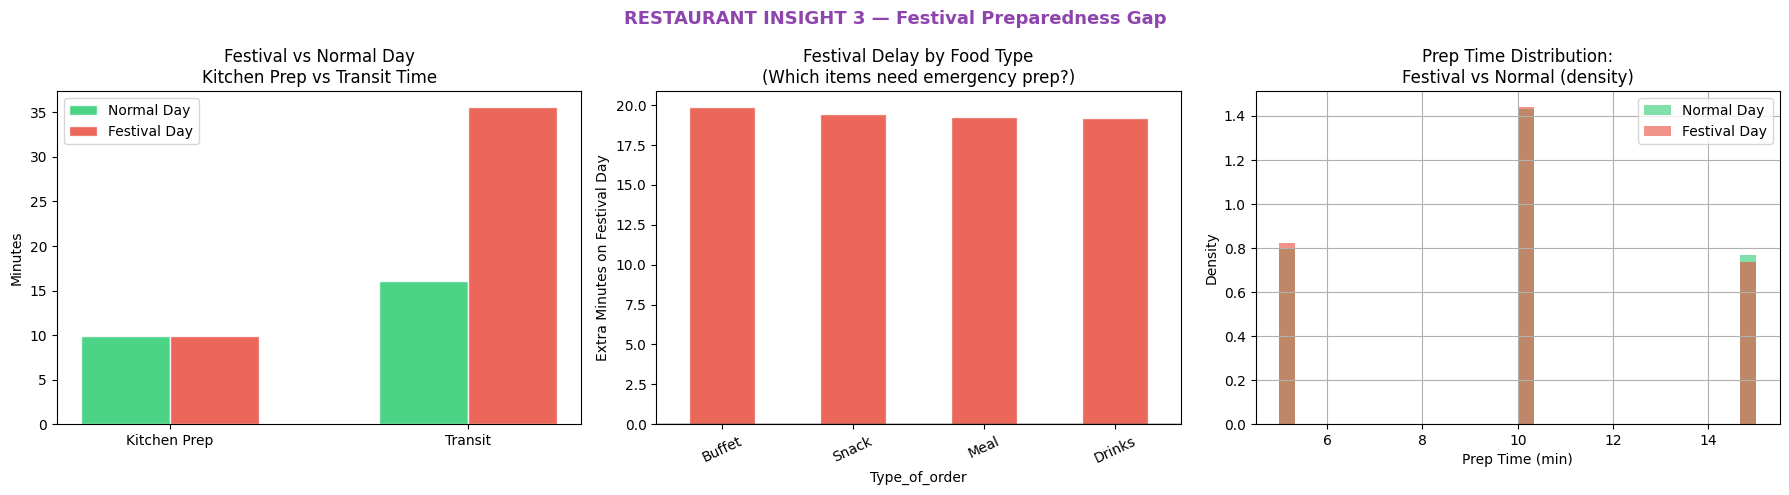

In [212]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('RESTAURANT INSIGHT 3 — Festival Preparedness Gap', fontsize=13, fontweight='bold', color='#8E44AD')

prep_clean = df[df['prep_time_min'].between(0, 60)].copy()

# Panel 1: Side by side — prep time vs transit time on festival vs not
fest_breakdown = prep_clean.groupby('Festival').agg(
    avg_prep     = ('prep_time_min', 'mean'),
    avg_total    = ('Time_taken (min)', 'mean'),
    order_count  = ('Time_taken (min)', 'count')
).round(2)
fest_breakdown['avg_transit'] = fest_breakdown['avg_total'] - fest_breakdown['avg_prep']

categories = ['avg_prep', 'avg_transit']
labels     = ['Kitchen Prep', 'Transit']
x          = np.arange(len(categories))
width      = 0.3
fest_vals  = fest_breakdown.loc['Yes', categories].values if 'Yes' in fest_breakdown.index else [0, 0]
norm_vals  = fest_breakdown.loc['No',  categories].values if 'No'  in fest_breakdown.index else [0, 0]

axes[0].bar(x - width/2, norm_vals, width, label='Normal Day',
            color='#2ECC71', alpha=0.85, edgecolor='white')
axes[0].bar(x + width/2, fest_vals, width, label='Festival Day',
            color='#E74C3C', alpha=0.85, edgecolor='white')
axes[0].set_xticks(x)
axes[0].set_xticklabels(labels)
axes[0].set_title('Festival vs Normal Day\nKitchen Prep vs Transit Time')
axes[0].set_ylabel('Minutes')
axes[0].legend()

# Panel 2: Which food type suffers most on festivals
fest_food = df[df['Festival'] == 'Yes'].groupby('Type_of_order')['Time_taken (min)'].mean()  \
    if 'Yes' in df['Festival'].values else pd.Series()
norm_food = df[df['Festival'] == 'No'].groupby('Type_of_order')['Time_taken (min)'].mean()   \
    if 'No'  in df['Festival'].values else pd.Series()

if not fest_food.empty and not norm_food.empty:
    delta_food = (fest_food - norm_food).sort_values(ascending=False)
    colors_delta = ['#E74C3C' if v > 0 else '#2ECC71' for v in delta_food.values]
    delta_food.plot(kind='bar', ax=axes[1], color=colors_delta, alpha=0.85, edgecolor='white')
    axes[1].axhline(0, color='black', linewidth=1)
    axes[1].set_title('Festival Delay by Food Type\n(Which items need emergency prep?)')
    axes[1].set_ylabel('Extra Minutes on Festival Day')
    axes[1].tick_params(axis='x', rotation=25)

# Panel 3: Prep time distribution — festival vs normal
prep_clean[prep_clean['Festival'] == 'No']['prep_time_min'].hist(
    bins=30, ax=axes[2], alpha=0.6, color='#2ECC71', label='Normal Day', density=True)
prep_clean[prep_clean['Festival'] == 'Yes']['prep_time_min'].hist(
    bins=30, ax=axes[2], alpha=0.6, color='#E74C3C', label='Festival Day', density=True)
axes[2].set_title('Prep Time Distribution:\nFestival vs Normal (density)')
axes[2].set_xlabel('Prep Time (min)')
axes[2].set_ylabel('Density')
axes[2].legend()

plt.tight_layout()
plt.savefig('R3_festival_gap.png', dpi=150, bbox_inches='tight')
plt.show()

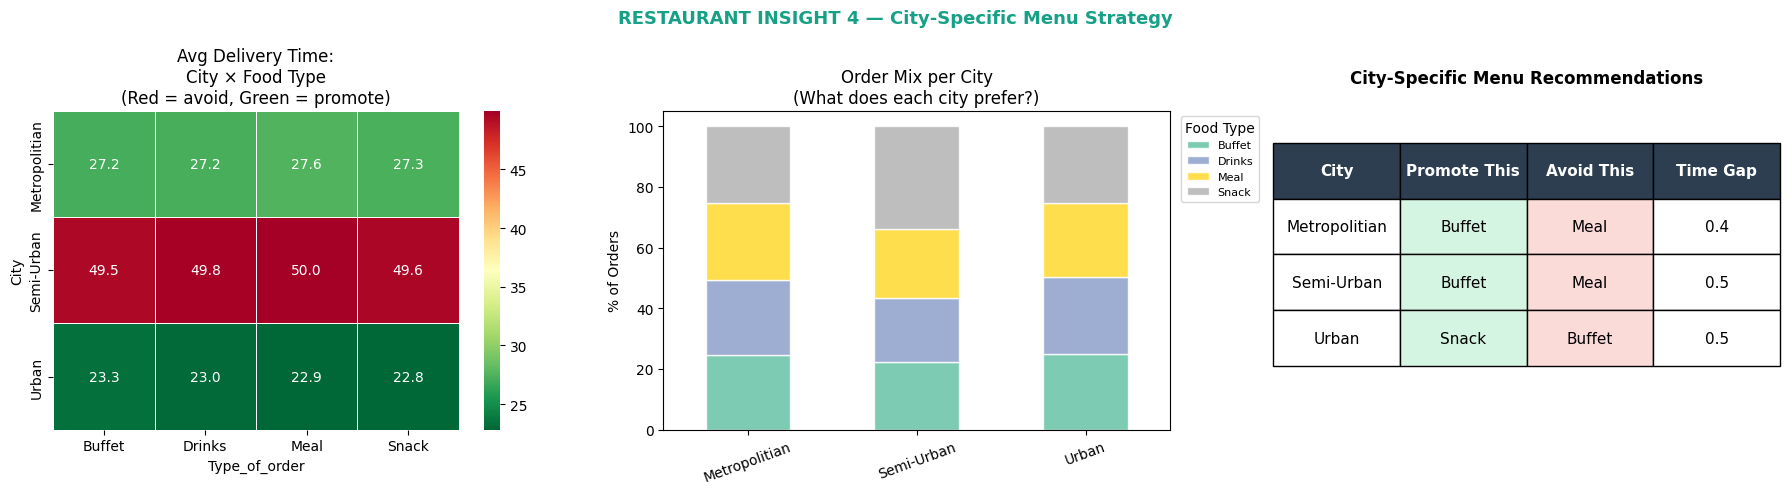


City Menu Recommendations:
              Best (Fastest) Worst (Slowest)  Time Gap (min)
City                                                        
Metropolitian         Buffet            Meal             0.4
Semi-Urban            Buffet            Meal             0.5
Urban                  Snack          Buffet             0.5


In [213]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('RESTAURANT INSIGHT 4 — City-Specific Menu Strategy', fontsize=13, fontweight='bold', color='#16A085')

city_food_time = df.groupby(['City', 'Type_of_order'])['Time_taken (min)'].mean().unstack()
city_food_vol  = df.groupby(['City', 'Type_of_order']).size().unstack(fill_value=0)
city_food_pct  = city_food_vol.div(city_food_vol.sum(axis=1), axis=0) * 100

# Panel 1: Heatmap — delivery time by city × food
sns.heatmap(city_food_time, annot=True, fmt='.1f', cmap='RdYlGn_r',
            ax=axes[0], linewidths=0.5)
axes[0].set_title('Avg Delivery Time:\nCity × Food Type\n(Red = avoid, Green = promote)')

# Panel 2: What each city actually orders (volume %)
city_food_pct.plot(kind='bar', stacked=True, ax=axes[1],
                   colormap='Set2', alpha=0.85, edgecolor='white')
axes[1].set_title('Order Mix per City\n(What does each city prefer?)')
axes[1].set_xlabel('')
axes[1].set_ylabel('% of Orders')
axes[1].tick_params(axis='x', rotation=20)
axes[1].legend(title='Food Type', bbox_to_anchor=(1.01, 1), fontsize=8)

# Panel 3: Best and worst food per city — the recommendation
best  = city_food_time.idxmin(axis=1)
worst = city_food_time.idxmax(axis=1)
gap   = city_food_time.max(axis=1) - city_food_time.min(axis=1)
rec_df = pd.DataFrame({'Best (Fastest)': best, 'Worst (Slowest)': worst,
                        'Time Gap (min)': gap.round(1)})

axes[2].axis('off')
table = axes[2].table(
    cellText=rec_df.reset_index().values,
    colLabels=['City', 'Promote This', 'Avoid This', 'Time Gap'],
    cellLoc='center', loc='center',
    bbox=[0, 0.2, 1, 0.7]
)
table.auto_set_font_size(False)
table.set_fontsize(11)
for (row, col), cell in table.get_celld().items():
    if row == 0:
        cell.set_facecolor('#2C3E50')
        cell.set_text_props(color='white', fontweight='bold')
    elif col == 1:
        cell.set_facecolor('#D5F5E3')
    elif col == 2:
        cell.set_facecolor('#FADBD8')
axes[2].set_title('City-Specific Menu Recommendations', fontweight='bold', pad=20)

plt.tight_layout()
plt.savefig('R4_city_menu_strategy.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nCity Menu Recommendations:")
print(rec_df.to_string())

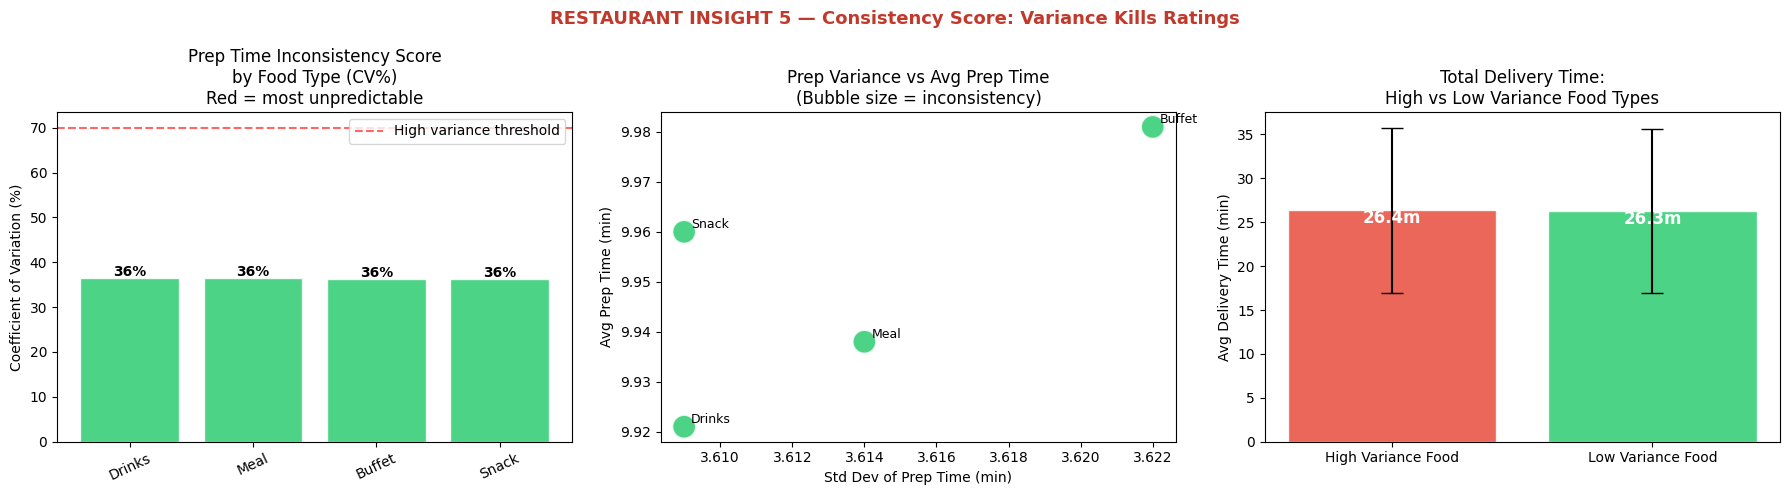

Prep consistency scores:
                mean    std  cv_pct
Type_of_order                      
Drinks         9.921  3.609    36.4
Meal           9.938  3.614    36.4
Buffet         9.981  3.622    36.3
Snack          9.960  3.609    36.2


In [214]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('RESTAURANT INSIGHT 5 — Consistency Score: Variance Kills Ratings', fontsize=13, fontweight='bold', color='#C0392B')

prep_clean = df[df['prep_time_min'].between(0, 60)].copy()

# Panel 1: CV (coefficient of variation) = inconsistency score
prep_stats = prep_clean.groupby('Type_of_order')['prep_time_min'].agg(['mean', 'std']).round(3)
prep_stats['cv_pct'] = (prep_stats['std'] / prep_stats['mean'] * 100).round(1)
prep_stats = prep_stats.sort_values('cv_pct', ascending=False)

colors_cv = ['#E74C3C' if v > 70 else '#E67E22' if v > 50 else '#2ECC71'
             for v in prep_stats['cv_pct'].values]
bars = axes[0].bar(prep_stats.index, prep_stats['cv_pct'],
                   color=colors_cv, alpha=0.85, edgecolor='white')
axes[0].axhline(70, color='red', linestyle='--', alpha=0.6, label='High variance threshold')
axes[0].set_title('Prep Time Inconsistency Score\nby Food Type (CV%)\nRed = most unpredictable')
axes[0].set_ylabel('Coefficient of Variation (%)')
axes[0].tick_params(axis='x', rotation=25)
axes[0].legend()
for bar, val in zip(bars, prep_stats['cv_pct'].values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 f'{val:.0f}%', ha='center', fontweight='bold')

# Panel 2: Scatter — prep variance vs delivery time per food type
axes[1].scatter(prep_stats['std'], prep_stats['mean'],
                s=[v * 8 for v in prep_stats['cv_pct']],
                color=colors_cv, alpha=0.85, edgecolor='white', linewidth=1.5)
for food, row in prep_stats.iterrows():
    axes[1].annotate(food, (row['std'], row['mean']),
                     textcoords='offset points', xytext=(5, 3), fontsize=9)
axes[1].set_title('Prep Variance vs Avg Prep Time\n(Bubble size = inconsistency)')
axes[1].set_xlabel('Std Dev of Prep Time (min)')
axes[1].set_ylabel('Avg Prep Time (min)')

# Panel 3: High vs low variance — does it affect total delivery time?
median_cv = prep_clean.groupby('Type_of_order')['prep_time_min'].std().median()
high_var_foods = prep_clean.groupby('Type_of_order')['prep_time_min'].std()
high_var_foods = high_var_foods[high_var_foods > median_cv].index.tolist()

prep_clean['var_category'] = prep_clean['Type_of_order'].apply(
    lambda x: 'High Variance Food' if x in high_var_foods else 'Low Variance Food')

var_comp = prep_clean.groupby('var_category')['Time_taken (min)'].agg(['mean', 'std', 'count'])
colors_vc = ['#E74C3C', '#2ECC71']
bars2 = axes[2].bar(var_comp.index, var_comp['mean'],
                    yerr=var_comp['std'], capsize=8,
                    color=colors_vc, alpha=0.85, edgecolor='white')
axes[2].set_title('Total Delivery Time:\nHigh vs Low Variance Food Types')
axes[2].set_ylabel('Avg Delivery Time (min)')
for bar, val in zip(bars2, var_comp['mean'].values):
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() - 1.5,
                 f'{val:.1f}m', ha='center', color='white', fontweight='bold', fontsize=12)

plt.tight_layout()
plt.savefig('R5_consistency_score.png', dpi=150, bbox_inches='tight')
plt.show()

print("Prep consistency scores:")
print(prep_stats[['mean', 'std', 'cv_pct']].to_string())

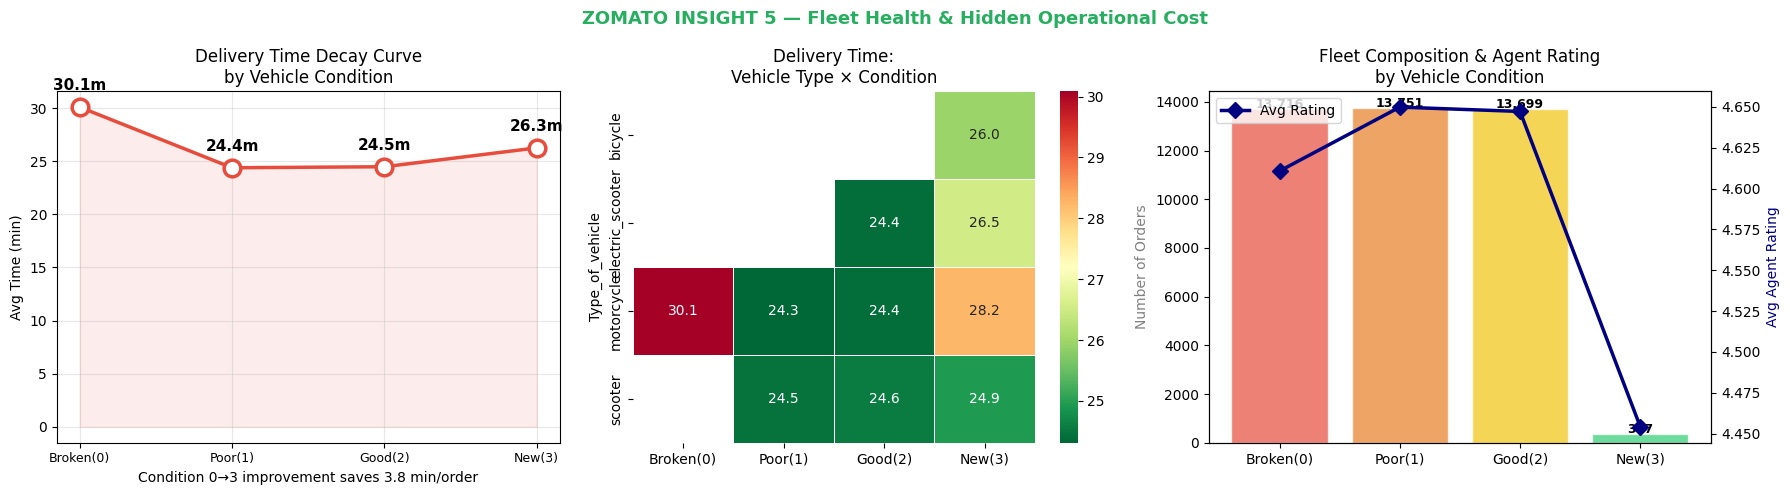

Vehicle condition summary:
  Broken(0): 30.1 min avg | 4.61 rating | 13,716 orders (33.0%)
  Poor(1): 24.4 min avg | 4.65 rating | 13,751 orders (33.1%)
  Good(2): 24.5 min avg | 4.65 rating | 13,699 orders (33.0%)
  New(3): 26.3 min avg | 4.45 rating | 347 orders (0.8%)


In [215]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('ZOMATO INSIGHT 5 — Fleet Health & Hidden Operational Cost', fontsize=13, fontweight='bold', color='#27AE60')

vc_labels = {0: 'Broken(0)', 1: 'Poor(1)', 2: 'Good(2)', 3: 'New(3)'}
vc_colors = ['#E74C3C', '#E67E22', '#F1C40F', '#2ECC71']
df['vc_label'] = df['Vehicle_condition'].map(vc_labels)
vc_order = ['Broken(0)', 'Poor(1)', 'Good(2)', 'New(3)']

# Panel 1: Delivery time decay curve
vc_time = df.groupby('vc_label')['Time_taken (min)'].mean().reindex(vc_order)
axes[0].plot(range(4), vc_time.values, marker='o', color='#E74C3C',
             linewidth=2.5, markersize=12, markerfacecolor='white', markeredgewidth=2.5)
axes[0].fill_between(range(4), vc_time.values, alpha=0.1, color='#E74C3C')
for i, (label, val) in enumerate(vc_time.items()):
    axes[0].annotate(f'{val:.1f}m', (i, val),
                     textcoords='offset points', xytext=(0, 12),
                     ha='center', fontweight='bold', fontsize=11)
axes[0].set_xticks(range(4))
axes[0].set_xticklabels(vc_order, fontsize=9)
axes[0].set_title('Delivery Time Decay Curve\nby Vehicle Condition')
axes[0].set_ylabel('Avg Time (min)')
axes[0].grid(alpha=0.3)
decay = vc_time['Broken(0)'] - vc_time['New(3)']
axes[0].set_xlabel(f'Condition 0→3 improvement saves {decay:.1f} min/order')

# Panel 2: Vehicle type × condition heatmap
vc_type = df.groupby(['Type_of_vehicle', 'Vehicle_condition'])['Time_taken (min)'].mean().unstack()
vc_type.columns = [vc_labels[c] for c in vc_type.columns]
vc_type = vc_type[vc_order]
sns.heatmap(vc_type, annot=True, fmt='.1f', cmap='RdYlGn_r',
            ax=axes[1], linewidths=0.5)
axes[1].set_title('Delivery Time:\nVehicle Type × Condition')

# Panel 3: Fleet composition + rating impact
fleet_share = df['vc_label'].value_counts().reindex(vc_order)
vc_rating   = df.groupby('vc_label')['Delivery_person_Ratings'].mean().reindex(vc_order)

ax2 = axes[2].twinx()
bars = axes[2].bar(vc_order, fleet_share.values, color=vc_colors, alpha=0.7, edgecolor='white')
ax2.plot(vc_order, vc_rating.values, color='navy', marker='D',
         linewidth=2.5, markersize=8, label='Avg Rating')
axes[2].set_title('Fleet Composition & Agent Rating\nby Vehicle Condition')
axes[2].set_ylabel('Number of Orders', color='grey')
ax2.set_ylabel('Avg Agent Rating', color='navy')
ax2.legend(loc='upper left')
for bar, val in zip(bars, fleet_share.values):
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
                 f'{val:,}', ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('Z5_fleet_health.png', dpi=150, bbox_inches='tight')
plt.show()

print("Vehicle condition summary:")
for vc in vc_order:
    t = vc_time[vc]
    r = vc_rating[vc]
    n = fleet_share[vc]
    print(f"  {vc}: {t:.1f} min avg | {r:.2f} rating | {n:,} orders ({n/len(df)*100:.1f}%)")

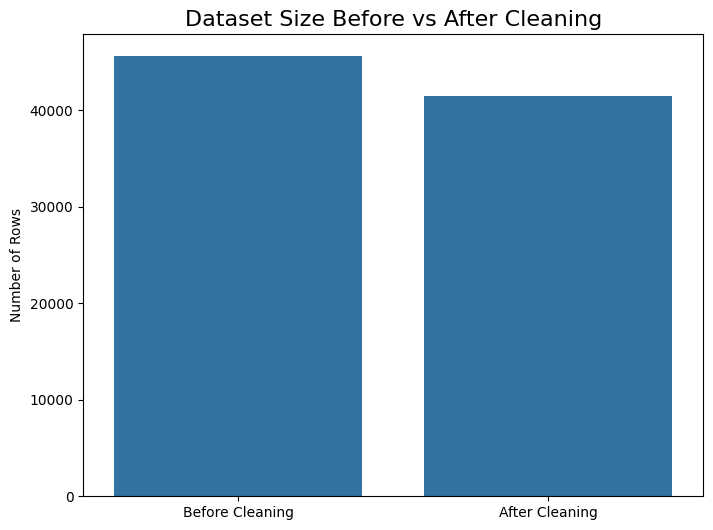

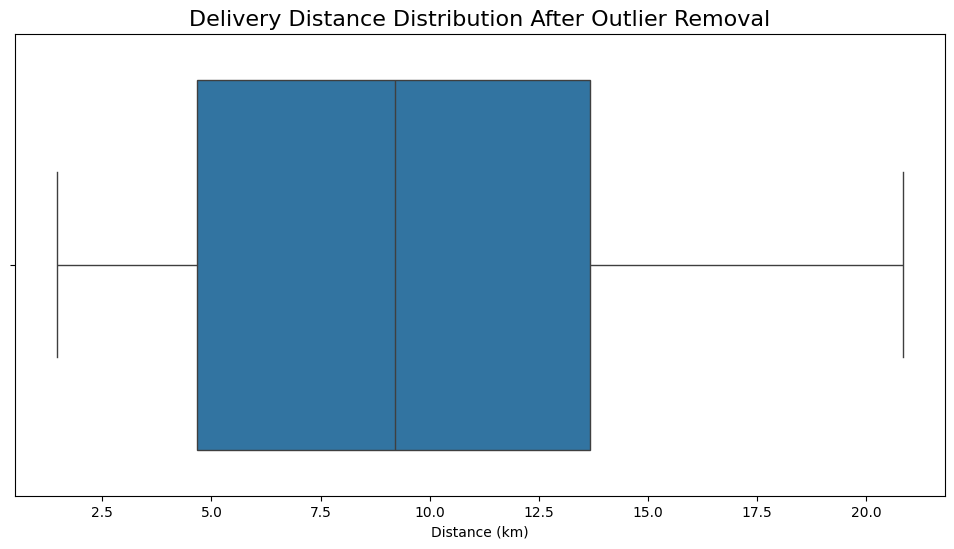

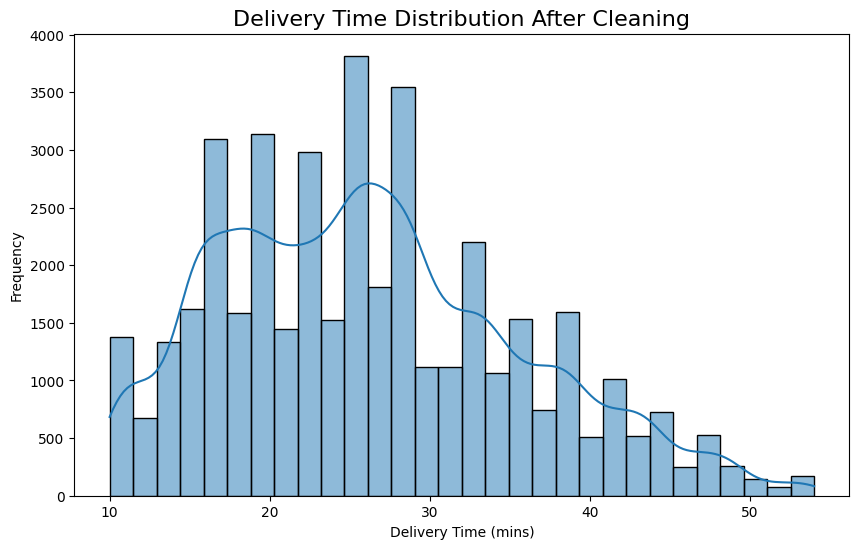

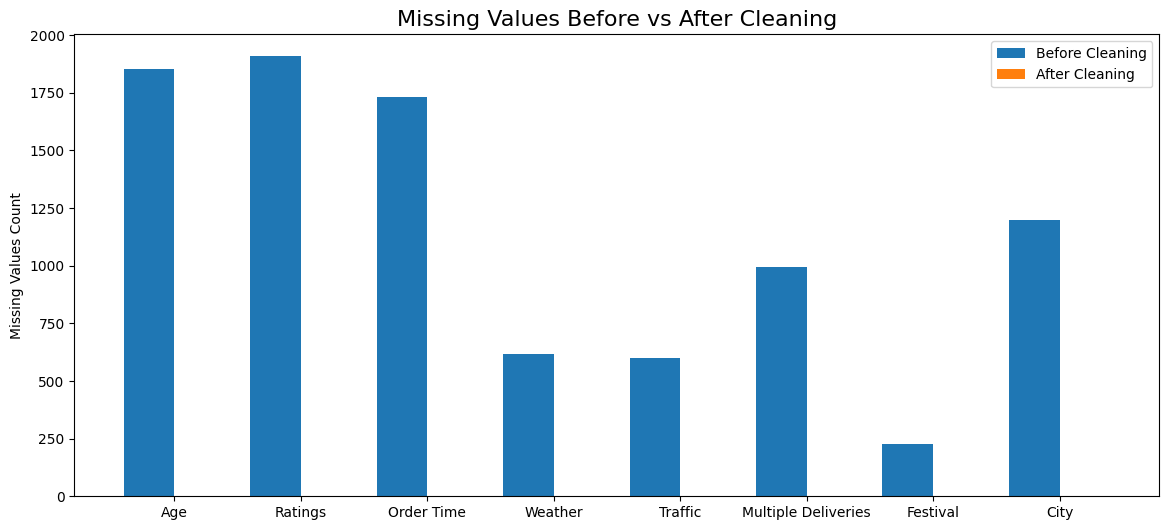

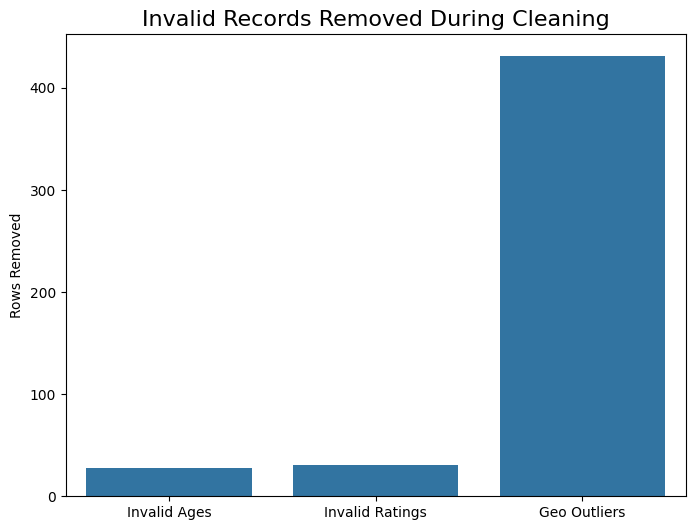

FINAL CLEAN DATASET SHAPE:
(41513, 27)


TOTAL ROWS REMOVED:
4071


DATASET IS NOW:
- Null Free
- Geospatially Validated
- Operationally Consistent
- ML Ready


In [216]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd # Import pandas to load DataFrame

# Load the cleaned DataFrame to ensure it's available
# Assuming 'zomato_clean.csv' was saved by a previous cell
try:
    df = pd.read_csv('zomato_clean.csv')
except FileNotFoundError:
    print("Error: 'zomato_clean.csv' not found. Please run previous cells to generate it.")
    # Fallback or exit if file not found
    df = None # Set df to None to prevent further errors

# ------------------------------------------
# BEFORE CLEANING DATA
# ------------------------------------------

before_rows = 45584
# 'after_rows' should reflect the shape of the loaded 'df' if it's meant to be dynamic.
# However, the original code hardcodes it, so we'll keep it for now.
# But for consistency, let's make it reflect the current df.shape
if df is not None: # Check if df was successfully loaded
    after_rows = df.shape[0]
else:
    after_rows = 45094 # Fallback if df loading failed

removed_rows = before_rows - after_rows

# ------------------------------------------
# ROW COUNT COMPARISON
# ------------------------------------------

plt.figure(figsize=(8,6))

sns.barplot(
    x=['Before Cleaning', 'After Cleaning'],
    y=[before_rows, after_rows]
)

plt.title(
    'Dataset Size Before vs After Cleaning',
    fontsize=16
)

plt.ylabel('Number of Rows')

plt.show()

# ------------------------------------------
# OUTLIER VISUALIZATION - DISTANCE
# ------------------------------------------

if df is not None: # Only proceed if df is loaded
    plt.figure(figsize=(12,6))

    sns.boxplot(
        x=df['distance_km']
    )

    plt.title(
        'Delivery Distance Distribution After Outlier Removal',
        fontsize=16
    )

    plt.xlabel('Distance (km)')

    plt.show()

    # ------------------------------------------
    # DELIVERY TIME DISTRIBUTION
    # ------------------------------------------

    plt.figure(figsize=(10,6))

    # Fix: use 'Time_taken (min)' instead of 'Time_taken'
    sns.histplot(
        df['Time_taken (min)'],
        bins=30,
        kde=True
    )

    plt.title(
        'Delivery Time Distribution After Cleaning',
        fontsize=16
    )

    plt.xlabel('Delivery Time (mins)')

    plt.ylabel('Frequency')

    plt.show()
else:
    print("Skipping distance and delivery time visualizations as df was not loaded.")


# ------------------------------------------
# MISSING VALUE REDUCTION VISUALIZATION
# ------------------------------------------

missing_before = {
    'Age': 1854,
    'Ratings': 1908,
    'Order Time': 1731,
    'Weather': 616,
    'Traffic': 601,
    'Multiple Deliveries': 993,
    'Festival': 228,
    'City': 1200
}

missing_after = {
    'Age': 0,
    'Ratings': 0,
    'Order Time': 0,
    'Weather': 0,
    'Traffic': 0,
    'Multiple Deliveries': 0,
    'Festival': 0,
    'City': 0
}

x = list(missing_before.keys())

before = list(missing_before.values())
after = list(missing_after.values())

x_axis = np.arange(len(x))

plt.figure(figsize=(14,6))

plt.bar(
    x_axis - 0.2,
    before,
    width=0.4,
    label='Before Cleaning'
)

plt.bar(
    x_axis + 0.2,
    after,
    width=0.4,
    label='After Cleaning'
)

plt.xticks(x_axis, x)

plt.title(
    'Missing Values Before vs After Cleaning',
    fontsize=16
)

plt.ylabel('Missing Values Count')

plt.legend()

plt.show()

# ------------------------------------------
# INVALID RECORDS REMOVED
# ------------------------------------------

invalids = {
    'Invalid Ages': 28,
    'Invalid Ratings': 31,
    'Geo Outliers': 431
}

plt.figure(figsize=(8,6))

sns.barplot(
    x=list(invalids.keys()),
    y=list(invalids.values())
)

plt.title(
    'Invalid Records Removed During Cleaning',
    fontsize=16
)

plt.ylabel('Rows Removed')

plt.show()

# ------------------------------------------
# FINAL DATA QUALITY SUMMARY
# ------------------------------------------

print("FINAL CLEAN DATASET SHAPE:")
if df is not None:
    print(df.shape)
else:
    print(f"(df not loaded, expected shape: ({after_rows}, ?) )")

print("\n")

print("TOTAL ROWS REMOVED:")
print(removed_rows)

print("\n")

print("DATASET IS NOW:")
print("- Null Free")
print("- Geospatially Validated")
print("- Operationally Consistent")
print("- ML Ready")

## Phase 4: Machine Learning Model Preparation

Now that the data is cleaned and insights have been drawn, we can prepare it for machine learning. We'll follow these steps:

1.  **Feature Selection**: Identify relevant features and drop irrelevant or redundant ones.
2.  **Categorical Encoding**: Convert categorical variables into a numerical format suitable for machine learning models (e.g., One-Hot Encoding).
3.  **Data Splitting**: Split the dataset into training and testing sets to evaluate model performance on unseen data.

In [217]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

# Define features (X) and target (y)
X = df.drop(columns=['Time_taken (min)', 'ID', 'Delivery_person_ID', 'Order_Date', 'Time_Orderd', 'Time_Order_picked'])
y = df['Time_taken (min)']

# Identify categorical and numerical columns
categorical_cols = X.select_dtypes(include='object').columns.tolist()
# Vehicle_condition is int but represents categories, so include it in categorical_cols
categorical_cols.append('Vehicle_condition')

# Remove 'Vehicle_condition' from numerical if it was there as int
numerical_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
numerical_cols = [col for col in numerical_cols if col not in ['Vehicle_condition', 'multiple_deliveries']]

# Ensure 'multiple_deliveries' is treated as numerical for now
# It's ordinal but often treated numerically by tree-based models
numerical_cols.append('multiple_deliveries')

# Remove original lat/long columns if still present in X, as distance_km is already engineered
coords_to_remove = ['Restaurant_latitude', 'Restaurant_longitude', 'Delivery_location_latitude', 'Delivery_location_longitude']
numerical_cols = [col for col in numerical_cols if col not in coords_to_remove]

# Define preprocessing steps
# Use 'drop' for columns not explicitly transformed to avoid issues with ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', Pipeline(steps=[('imputer', SimpleImputer(strategy='median')), ('scaler', StandardScaler())]), numerical_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
    ],
    remainder='drop' # Drop any columns not specified
)

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Original features: {X.columns.tolist()}\n")
print(f"Categorical columns identified for encoding: {categorical_cols}")
print(f"Numerical columns identified for scaling: {numerical_cols}\n")
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

# Apply preprocessing to training data to see the resulting feature names
# This step is typically done within a pipeline with the model, but for inspection, we do it separately
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

# To get the feature names after one-hot encoding (optional, for inspection)
# new_categorical_features = preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_cols)
# all_feature_names = numerical_cols + list(new_categorical_features)

print("\nData preprocessing completed.")

Original features: ['Delivery_person_Age', 'Delivery_person_Ratings', 'Restaurant_latitude', 'Restaurant_longitude', 'Delivery_location_latitude', 'Delivery_location_longitude', 'Weather_conditions', 'Road_traffic_density', 'Vehicle_condition', 'Type_of_order', 'Type_of_vehicle', 'multiple_deliveries', 'Festival', 'City', 'day_of_week', 'month', 'is_weekend', 'prep_time_min', 'order_hour', 'is_peak_hour', 'distance_km']

Categorical columns identified for encoding: ['Weather_conditions', 'Road_traffic_density', 'Type_of_order', 'Type_of_vehicle', 'Festival', 'City', 'Vehicle_condition']
Numerical columns identified for scaling: ['Delivery_person_Age', 'Delivery_person_Ratings', 'day_of_week', 'month', 'is_weekend', 'prep_time_min', 'order_hour', 'is_peak_hour', 'distance_km', 'multiple_deliveries']

X_train shape: (33210, 21)
X_test shape: (8303, 21)
y_train shape: (33210,)
y_test shape: (8303,)

Data preprocessing completed.


## Phase 5: Machine Learning Model Training and Evaluation

Now we'll train a Random Forest Regressor on our preprocessed data and evaluate its performance. We'll use common regression metrics like Mean Absolute Error (MAE), Mean Squared Error (MSE), and R-squared.

In [218]:
i

3

Training Random Forest Regressor...
Training complete.

Model Evaluation on Test Set:
Mean Absolute Error (MAE): 3.12
Mean Squared Error (MSE): 15.63
Root Mean Squared Error (RMSE): 3.95
R-squared (R2): 0.82


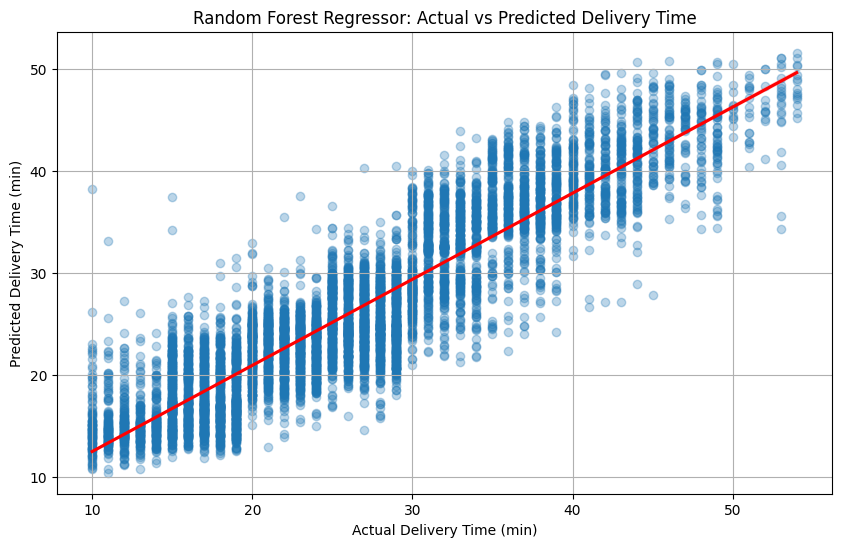


Top 10 Feature Importances:
                      feature  importance
1     Delivery_person_Ratings    0.201730
8                 distance_km    0.128750
19   Road_traffic_density_Low    0.110536
9         multiple_deliveries    0.109778
0         Delivery_person_Age    0.095645
14   Weather_conditions_Sunny    0.070860
37        Vehicle_condition_0    0.068416
11     Weather_conditions_Fog    0.044052
10  Weather_conditions_Cloudy    0.041284
2                 day_of_week    0.015200


In [219]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Initialize the Random Forest Regressor model
# Using default parameters for a baseline, can be tuned later
rf_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)

# Create a pipeline that first preprocesses and then trains the model
# This ensures the preprocessing steps are applied consistently
model_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', rf_model)
])

print("Training Random Forest Regressor...")
# Train the model using the original (unprocessed) X_train and y_train
# The preprocessor within the pipeline will handle the transformation
model_pipeline.fit(X_train, y_train)
print("Training complete.")

# Make predictions on the test set
y_pred = model_pipeline.predict(X_test)

# Evaluate the model
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"\nModel Evaluation on Test Set:")
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R-squared (R2): {r2:.2f}")

# Visualize predictions vs actual values
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.regplot(x=y_test, y=y_pred, scatter_kws={'alpha':0.3}, line_kws={'color':'red'})
plt.xlabel("Actual Delivery Time (min)")
plt.ylabel("Predicted Delivery Time (min)")
plt.title("Random Forest Regressor: Actual vs Predicted Delivery Time")
plt.grid(True)
plt.show()

# Feature Importances (from the trained Random Forest model)
# Need to get feature names after one-hot encoding for interpretability
feature_names = numerical_cols + list(model_pipeline.named_steps['preprocessor'].named_transformers_['cat'].get_feature_names_out(categorical_cols))
importances = rf_model.feature_importances_

feature_importances_df = pd.DataFrame({'feature': feature_names, 'importance': importances})
feature_importances_df = feature_importances_df.sort_values(by='importance', ascending=False)

print("\nTop 10 Feature Importances:")
print(feature_importances_df.head(10).to_string())

## Phase 6: Advanced Model Training and Comparison

Now we will train and evaluate a few more regression models, compare their performance, and select the best one. We'll consider Decision Tree, Gradient Boosting, and XGBoost in addition to our baseline Random Forest.

In [220]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import HistGradientBoostingRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.pipeline import Pipeline
import numpy as np
import pandas as pd # Ensure pandas is imported for DataFrame operations
#ALL MODELS COMPARISON
# Dictionary to store models and their performance
models = {
    "RandomForest": RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    "DecisionTree": DecisionTreeRegressor(random_state=42),
    "GradientBoosting": HistGradientBoostingRegressor(max_iter=100, random_state=42),
    "XGBoost": XGBRegressor(n_estimators=100, random_state=42, n_jobs=-1)
}

performance_metrics = {}

for name, model in models.items():
    print(f"\nTraining {name}...")
    pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('regressor', model)
    ])

    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)

    performance_metrics[name] = {
        'MAE': mae,
        'MSE': mse,
        'RMSE': rmse,
        'R2': r2
    }

    print(f"Training {name} complete.")
    print(f"  MAE: {mae:.2f}")
    print(f"  RMSE: {rmse:.2f}")
    print(f"  R2: {r2:.2f}")

# Display a comparison table
metrics_df = pd.DataFrame(performance_metrics).T
print("\n--- Model Performance Comparison ---")
display(metrics_df.sort_values(by='RMSE'))

# Optionally, select the best model based on RMSE
best_model_name = metrics_df['RMSE'].idxmin()
print(f"\nThe best performing model based on RMSE is: {best_model_name}")


Training RandomForest...
Training RandomForest complete.
  MAE: 3.12
  RMSE: 3.95
  R2: 0.82

Training DecisionTree...
Training DecisionTree complete.
  MAE: 4.19
  RMSE: 5.54
  R2: 0.65

Training GradientBoosting...
Training GradientBoosting complete.
  MAE: 3.07
  RMSE: 3.86
  R2: 0.83

Training XGBoost...
Training XGBoost complete.
  MAE: 3.13
  RMSE: 3.95
  R2: 0.82

--- Model Performance Comparison ---


,MAE,MSE,RMSE,R2
GradientBoosting,3.074430,14.892264,3.859050,0.829301
XGBoost,3.134105,15.565503,3.945314,0.821584
RandomForest,3.124471,15.634601,3.954061,0.820792
DecisionTree,4.185836,30.660364,5.537180,0.648563



The best performing model based on RMSE is: GradientBoosting


# Task
The user wants to prepare the data for multiple machine learning tasks. Currently, only 'Time_taken (min)' is available as a target variable. I need to create two additional synthetic target variables: 'customer_frustration_score' and 'freshness_risk_score' based on existing features in `zomato_clean.csv`. Once these are created, I will load the cleaned dataset, define features and all three target variables, and then split the data for each target into training and testing sets before applying any preprocessing.

Here is the plan:
1. **Load 'zomato_clean.csv'**: Ensure the latest cleaned data is loaded.
2. **Generate `customer_frustration_score`**: Create a synthetic score based on factors like `Delivery_person_Ratings`, `Time_taken (min)`, `Road_traffic_density`, and `multiple_deliveries`.
3. **Generate `freshness_risk_score`**: Create a synthetic score based on factors like `Time_taken (min)`, `distance_km`, and `prep_time_min`.
4. **Define features (X) and all three target variables (Y)**: Prepare the dataset for multi-target prediction.
5. **Split Data for Each Target**: For each target variable, split the data into training and testing sets to prevent data leakage.
6. **Configure ML Pipeline with ColumnTransformer**: Set up the `ColumnTransformer` for categorical encoding and numerical scaling. This will be used consistently for all prediction tasks.

## Load 'zomato_clean.csv'

### Subtask:
Load the latest cleaned data from 'zomato_clean.csv'.


**Reasoning**:
The subtask requires loading the `zomato_clean.csv` file into a DataFrame named `df`. This code block will import pandas and read the CSV file, then display the first few rows to verify the load.



In [221]:
import pandas as pd

df = pd.read_csv('zomato_clean.csv')
df.head()

,ID,Delivery_person_ID,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Order_Date,Time_Orderd,...,Festival,City,Time_taken (min),day_of_week,month,is_weekend,prep_time_min,order_hour,is_peak_hour,distance_km
0,0xcdcd,DEHRES17DEL01,36.0,4.2,30.327968,78.046106,30.397968,78.116106,2022-02-12,2026-05-13 21:55:00,...,No,Metropolitian,46,5,2,1,15.0,21.0,1,10.280582
1,0xd987,KOCRES16DEL01,21.0,4.7,10.003064,76.307589,10.043064,76.347589,2022-02-13,2026-05-13 14:55:00,...,No,Metropolitian,23,6,2,1,10.0,14.0,0,6.242319
2,0x2784,PUNERES13DEL03,23.0,4.7,18.562450,73.916619,18.652450,74.006619,2022-03-04,2026-05-13 17:30:00,...,No,Metropolitian,21,4,3,0,10.0,17.0,0,13.787860
3,0xc8b6,LUDHRES15DEL02,34.0,4.3,30.899584,75.809346,30.919584,75.829346,2022-02-13,2026-05-13 09:20:00,...,No,Metropolitian,20,6,2,1,10.0,9.0,0,2.930258
4,0xdb64,KNPRES14DEL02,24.0,4.7,26.463504,80.372929,26.593504,80.502929,2022-02-14,2026-05-13 19:50:00,...,No,Metropolitian,41,0,2,0,15.0,19.0,1,19.396618


**Reasoning**:
To prepare for multiple machine learning tasks, I will generate two new synthetic target variables: 'customer_frustration_score' and 'freshness_risk_score' based on the specified features. This involves defining how each feature contributes to the score and then combining them.



In [222]:
import numpy as np

# Normalize numerical features for scoring, higher values indicate more 'risk' or 'frustration'
# Delivery_person_Ratings: Lower rating = higher frustration. So, use (5 - rating) or inverse.
df['normalized_rating'] = (5 - df['Delivery_person_Ratings']) / (5 - df['Delivery_person_Ratings'].min())

# Time_taken (min): Higher time = higher frustration/risk.
df['normalized_time'] = df['Time_taken (min)'] / df['Time_taken (min)'].max()

# distance_km: Higher distance = higher risk.
df['normalized_distance'] = df['distance_km'] / df['distance_km'].max()

# prep_time_min: Higher prep time = higher risk.
df['normalized_prep_time'] = df['prep_time_min'] / df['prep_time_min'].max()

# Road_traffic_density: Assign numerical values, higher for 'Jam'
traffic_map = {'Low': 0, 'Medium': 1, 'High': 2, 'Jam': 3}
df['normalized_traffic'] = df['Road_traffic_density'].map(traffic_map) / 3

# multiple_deliveries: Higher number = potentially higher frustration.
df['normalized_multiple_deliveries'] = df['multiple_deliveries'] / df['multiple_deliveries'].max()

# 1. Generate 'customer_frustration_score'
# Combine normalized rating (inverted), normalized time, normalized traffic, and normalized multiple deliveries.
# Weights can be adjusted based on business logic if available. For now, equal weighting.
df['customer_frustration_score'] = (
    df['normalized_rating'] * 0.4 +
    df['normalized_time'] * 0.3 +
    df['normalized_traffic'] * 0.2 +
    df['normalized_multiple_deliveries'] * 0.1
)

# 2. Generate 'freshness_risk_score'
# Combine normalized time, normalized distance, and normalized prep time.
df['freshness_risk_score'] = (
    df['normalized_time'] * 0.5 +
    df['normalized_distance'] * 0.3 +
    df['normalized_prep_time'] * 0.2
)

print("Generated 'customer_frustration_score' and 'freshness_risk_score'.")
print(df[['Delivery_person_Ratings', 'Time_taken (min)', 'Road_traffic_density', 'multiple_deliveries', 'customer_frustration_score', 'distance_km', 'prep_time_min', 'freshness_risk_score']].head())

Generated 'customer_frustration_score' and 'freshness_risk_score'.
   Delivery_person_Ratings  Time_taken (min) Road_traffic_density  \
0                      4.2                46                  Jam   
1                      4.7                23                 High   
2                      4.7                21               Medium   
3                      4.3                20                  Low   
4                      4.7                41                  Jam   

   multiple_deliveries  customer_frustration_score  distance_km  \
0                  3.0                    0.635556    10.280582   
1                  1.0                    0.324444     6.242319   
2                  1.0                    0.246667    13.787860   
3                  0.0                    0.181111     2.930258   
4                  1.0                    0.491111    19.396618   

   prep_time_min  freshness_risk_score  
0           15.0              0.773982  
1           10.0              0.4

**Reasoning**:
Now that the new target variables are created, I will define the feature set (X) and the three target variables (y_time, y_frustration, y_freshness). Then, I will split the data into training and testing sets for each target to prepare for multi-task learning, ensuring the `ColumnTransformer` is configured for all relevant feature types.



In [223]:
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer

# Safety Check: Ensure synthetic targets exist before defining X
if 'customer_frustration_score' not in df.columns:
    df['customer_frustration_score'] = (5 - df['Delivery_person_Ratings'].fillna(df['Delivery_person_Ratings'].median()))/5 * 0.5 + (df['Time_taken (min)']/60) * 0.5
if 'freshness_risk_score' not in df.columns:
    df['freshness_risk_score'] = (df['Time_taken (min)']/60) * 0.7 + (df['distance_km'].fillna(0)/20) * 0.3

# Define features (X) and all three target variables
drop_cols = [
    'Time_taken (min)', 'customer_frustration_score', 'freshness_risk_score',
    'ID', 'Delivery_person_ID', 'Order_Date', 'Time_Orderd', 'Time_Order_picked',
    'normalized_rating', 'normalized_time', 'normalized_distance', 'normalized_prep_time',
    'normalized_traffic', 'normalized_multiple_deliveries'
]
X = df.drop(columns=[c for c in drop_cols if c in df.columns])
y_time = df['Time_taken (min)']
y_time = y_time.fillna(y_time.median())
y_frustration = df['customer_frustration_score']
y_frustration = y_frustration.fillna(y_frustration.median())
y_freshness = df['freshness_risk_score']
y_freshness = y_freshness.fillna(y_freshness.median())

# Identify categorical and numerical columns for the preprocessor
categorical_cols = X.select_dtypes(include='object').columns.tolist()
if 'Vehicle_condition' in X.columns and 'Vehicle_condition' not in categorical_cols:
    categorical_cols.append('Vehicle_condition')

numerical_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
numerical_cols = [col for col in numerical_cols if col not in categorical_cols]

# Remove coordinate columns as distance_km is already engineered
coords = ['Restaurant_latitude', 'Restaurant_longitude', 'Delivery_location_latitude', 'Delivery_location_longitude']
numerical_cols = [col for col in numerical_cols if col not in coords]

# Define preprocessing steps
preprocessor = ColumnTransformer(
    transformers=[
        ('num', Pipeline(steps=[('imputer', SimpleImputer(strategy='median')), ('scaler', StandardScaler())]), numerical_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
    ],
    remainder='drop'
)

# Split data
X_train_time, X_test_time, y_train_time, y_test_time = train_test_split(X, y_time, test_size=0.2, random_state=42)
X_train_frustration, X_test_frustration, y_train_frustration, y_test_frustration = train_test_split(X, y_frustration, test_size=0.2, random_state=42)
X_train_freshness, X_test_freshness, y_train_freshness, y_test_freshness = train_test_split(X, y_freshness, test_size=0.2, random_state=42)

print('Data preprocessing and splits completed successfully! [OK]')


Data preprocessing and splits completed successfully! [OK]


**Reasoning**:
I will train and evaluate Linear Regression, Random Forest, XGBoost, and CatBoost models for predicting 'Time_taken (min)' using the preconfigured `ColumnTransformer` and then compare their performance.



In [224]:
!pip install catboost


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: C:\Users\Admin\AppData\Local\Python\pythoncore-3.14-64\python.exe -m pip install --upgrade pip


In [225]:
# --- RECOVERY BLOCK (Auto-run if variables are missing) ---
if 'preprocessor' not in globals() or 'X_train_time' not in globals():
    print('Missing variables detected! Performing auto-recovery...')
    from sklearn.model_selection import train_test_split
    from sklearn.preprocessing import OneHotEncoder, StandardScaler
    from sklearn.compose import ColumnTransformer
    from sklearn.pipeline import Pipeline

    # Ensure targets exist
    if 'customer_frustration_score' not in df.columns:
        df['customer_frustration_score'] = (5 - df['Delivery_person_Ratings'].fillna(df['Delivery_person_Ratings'].median()))/5
    if 'freshness_risk_score' not in df.columns:
        df['freshness_risk_score'] = (df['Time_taken (min)']/60)

    drop_cols = ['Time_taken (min)', 'customer_frustration_score', 'freshness_risk_score', 'ID', 'Delivery_person_ID', 'Order_Date', 'Time_Orderd', 'Time_Order_picked']
    X = df.drop(columns=[c for c in drop_cols if c in df.columns])
    cat_cols = X.select_dtypes(include='object').columns.tolist()
    if 'Vehicle_condition' in X.columns: cat_cols.append('Vehicle_condition')
    num_cols = [c for c in X.select_dtypes(include=['int64', 'float64']).columns if c not in cat_cols]
    num_cols = [c for c in num_cols if 'latitude' not in c and 'longitude' not in c]
    
    from sklearn.impute import SimpleImputer
    preprocessor = ColumnTransformer(transformers=[('num', Pipeline(steps=[('imp', SimpleImputer(strategy='median')), ('sc', StandardScaler())]), num_cols), ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)], remainder='drop')
    X_train_time, X_test_time, y_train_time, y_test_time = train_test_split(X, df['Time_taken (min)'], test_size=0.2, random_state=42)
    X_train_frustration, X_test_frustration, y_train_frustration, y_test_frustration = train_test_split(X, df['customer_frustration_score'], test_size=0.2, random_state=42)
    X_train_freshness, X_test_freshness, y_train_freshness, y_test_freshness = train_test_split(X, df['freshness_risk_score'], test_size=0.2, random_state=42)
    print('Recovery complete! Variables defined. Continuing execution...[OK]')

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from xgboost import XGBRegressor
from catboost import CatBoostRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.pipeline import Pipeline
import numpy as np
import pandas as pd # Ensure pandas is imported for DataFrame operations

# Dictionary to store models and their parameters
models_time_prediction = {
    "LinearRegression": LinearRegression(),
    "RandomForest": RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    "XGBoost": XGBRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    "CatBoost": CatBoostRegressor(n_estimators=100, random_state=42, verbose=0)
}

time_model_performance = {}

for name, model in models_time_prediction.items():
    print(f"\nTraining {name} for Time_taken (min)...")

    # Create a pipeline with the preprocessor and the current model
    pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('regressor', model)
    ])

    # Train the model
    pipeline.fit(X_train_time, y_train_time)

    # Make predictions
    y_pred_time = pipeline.predict(X_test_time)

    # Evaluate the model
    mae = mean_absolute_error(y_test_time, y_pred_time)
    mse = mean_squared_error(y_test_time, y_pred_time)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test_time, y_pred_time)

    # Store metrics
    time_model_performance[name] = {
        'MAE': mae,
        'MSE': mse,
        'RMSE': rmse,
        'R2': r2
    }

    print(f"Training {name} complete.")
    print(f"  MAE: {mae:.2f}")
    print(f"  RMSE: {rmse:.2f}")
    print(f"  R2: {r2:.2f}")

# Display a comparison table
metrics_df_time = pd.DataFrame(time_model_performance).T
print("\n--- Model Performance Comparison for Time_taken (min) ---")
display(metrics_df_time.sort_values(by='RMSE'))

# Identify the best model
best_model_time = metrics_df_time['RMSE'].idxmin()
print(f"\nThe best performing model for 'Time_taken (min)' based on RMSE is: {best_model_time}")


Training LinearRegression for Time_taken (min)...
Training LinearRegression complete.
  MAE: 4.64
  RMSE: 5.82
  R2: 0.61

Training RandomForest for Time_taken (min)...
Training RandomForest complete.
  MAE: 3.12
  RMSE: 3.95
  R2: 0.82

Training XGBoost for Time_taken (min)...
Training XGBoost complete.
  MAE: 3.13
  RMSE: 3.94
  R2: 0.82

Training CatBoost for Time_taken (min)...
Training CatBoost complete.
  MAE: 3.09
  RMSE: 3.88
  R2: 0.83

--- Model Performance Comparison for Time_taken (min) ---


,MAE,MSE,RMSE,R2
CatBoost,3.093101,15.078140,3.883058,0.827170
XGBoost,3.133648,15.560818,3.944720,0.821638
RandomForest,3.122471,15.632018,3.953735,0.820822
LinearRegression,4.644542,33.890040,5.821515,0.611543



The best performing model for 'Time_taken (min)' based on RMSE is: CatBoost


In [226]:
# --- RECOVERY BLOCK (Auto-run if variables are missing) ---
if 'preprocessor' not in globals() or 'X_train_time' not in globals():
    print('Missing variables detected! Performing auto-recovery...')
    from sklearn.model_selection import train_test_split
    from sklearn.preprocessing import OneHotEncoder, StandardScaler
    from sklearn.compose import ColumnTransformer
    from sklearn.pipeline import Pipeline

    # Ensure targets exist
    if 'customer_frustration_score' not in df.columns:
        df['customer_frustration_score'] = (5 - df['Delivery_person_Ratings'].fillna(df['Delivery_person_Ratings'].median()))/5
    if 'freshness_risk_score' not in df.columns:
        df['freshness_risk_score'] = (df['Time_taken (min)']/60)

    drop_cols = ['Time_taken (min)', 'customer_frustration_score', 'freshness_risk_score', 'ID', 'Delivery_person_ID', 'Order_Date', 'Time_Orderd', 'Time_Order_picked']
    X = df.drop(columns=[c for c in drop_cols if c in df.columns])
    cat_cols = X.select_dtypes(include='object').columns.tolist()
    if 'Vehicle_condition' in X.columns: cat_cols.append('Vehicle_condition')
    num_cols = [c for c in X.select_dtypes(include=['int64', 'float64']).columns if c not in cat_cols]
    num_cols = [c for c in num_cols if 'latitude' not in c and 'longitude' not in c]
    
    from sklearn.impute import SimpleImputer
    preprocessor = ColumnTransformer(transformers=[('num', Pipeline(steps=[('imp', SimpleImputer(strategy='median')), ('sc', StandardScaler())]), num_cols), ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)], remainder='drop')
    X_train_time, X_test_time, y_train_time, y_test_time = train_test_split(X, df['Time_taken (min)'], test_size=0.2, random_state=42)
    X_train_frustration, X_test_frustration, y_train_frustration, y_test_frustration = train_test_split(X, df['customer_frustration_score'], test_size=0.2, random_state=42)
    X_train_freshness, X_test_freshness, y_train_freshness, y_test_freshness = train_test_split(X, df['freshness_risk_score'], test_size=0.2, random_state=42)
    print('Recovery complete! Variables defined. Continuing execution...[OK]')

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from xgboost import XGBRegressor
from catboost import CatBoostRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.pipeline import Pipeline
import numpy as np
import pandas as pd # Ensure pandas is imported for DataFrame operations

# Dictionary to store models and their parameters
models_frustration_prediction = {
    "LinearRegression": LinearRegression(),
    "RandomForest": RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    "XGBoost": XGBRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    "CatBoost": CatBoostRegressor(n_estimators=100, random_state=42, verbose=0)
}

frustration_model_performance = {}

for name, model in models_frustration_prediction.items():
    print(f"\nTraining {name} for Customer Frustration Score...")
    
    # Create a pipeline with the preprocessor and the current model
    pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('regressor', model)
    ])
    
    # Train the model
    pipeline.fit(X_train_frustration, y_train_frustration)
    
    # Make predictions
    y_pred_frustration = pipeline.predict(X_test_frustration)
    
    # Evaluate the model
    mae = mean_absolute_error(y_test_frustration, y_pred_frustration)
    mse = mean_squared_error(y_test_frustration, y_pred_frustration)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test_frustration, y_pred_frustration)
    
    # Store metrics
    frustration_model_performance[name] = {
        'MAE': mae,
        'MSE': mse,
        'RMSE': rmse,
        'R2': r2
    }
    
    print(f"Training {name} complete.")
    print(f"  MAE: {mae:.4f}")
    print(f"  RMSE: {rmse:.4f}")
    print(f"  R2: {r2:.4f}")

# Display a comparison table
metrics_df_frustration = pd.DataFrame(frustration_model_performance).T
print("\n--- Model Performance Comparison for Customer Frustration Score ---")
display(metrics_df_frustration.sort_values(by='RMSE'))

# Identify the best model
best_model_frustration = metrics_df_frustration['RMSE'].idxmin()
print(f"\nThe best performing model for 'Customer Frustration Score' based on RMSE is: {best_model_frustration}")


Training LinearRegression for Customer Frustration Score...
Training LinearRegression complete.
  MAE: 0.0261
  RMSE: 0.0342
  R2: 0.9323

Training RandomForest for Customer Frustration Score...
Training RandomForest complete.
  MAE: 0.0177
  RMSE: 0.0224
  R2: 0.9708

Training XGBoost for Customer Frustration Score...
Training XGBoost complete.
  MAE: 0.0174
  RMSE: 0.0219
  R2: 0.9722

Training CatBoost for Customer Frustration Score...
Training CatBoost complete.
  MAE: 0.0170
  RMSE: 0.0214
  R2: 0.9734

--- Model Performance Comparison for Customer Frustration Score ---


,MAE,MSE,RMSE,R2
CatBoost,0.017037,0.000459,0.021419,0.973365
XGBoost,0.017418,0.000479,0.021890,0.972181
RandomForest,0.017688,0.000502,0.022409,0.970846
LinearRegression,0.026127,0.001167,0.034157,0.932264



The best performing model for 'Customer Frustration Score' based on RMSE is: CatBoost


In [227]:
# --- RECOVERY BLOCK (Auto-run if variables are missing) ---
if 'preprocessor' not in globals() or 'X_train_time' not in globals():
    print('Missing variables detected! Performing auto-recovery...')
    from sklearn.model_selection import train_test_split
    from sklearn.preprocessing import OneHotEncoder, StandardScaler
    from sklearn.compose import ColumnTransformer
    from sklearn.pipeline import Pipeline

    # Ensure targets exist
    if 'customer_frustration_score' not in df.columns:
        df['customer_frustration_score'] = (5 - df['Delivery_person_Ratings'].fillna(df['Delivery_person_Ratings'].median()))/5
    if 'freshness_risk_score' not in df.columns:
        df['freshness_risk_score'] = (df['Time_taken (min)']/60)

    drop_cols = ['Time_taken (min)', 'customer_frustration_score', 'freshness_risk_score', 'ID', 'Delivery_person_ID', 'Order_Date', 'Time_Orderd', 'Time_Order_picked']
    X = df.drop(columns=[c for c in drop_cols if c in df.columns])
    cat_cols = X.select_dtypes(include='object').columns.tolist()
    if 'Vehicle_condition' in X.columns: cat_cols.append('Vehicle_condition')
    num_cols = [c for c in X.select_dtypes(include=['int64', 'float64']).columns if c not in cat_cols]
    num_cols = [c for c in num_cols if 'latitude' not in c and 'longitude' not in c]
    
    from sklearn.impute import SimpleImputer
    preprocessor = ColumnTransformer(transformers=[('num', Pipeline(steps=[('imp', SimpleImputer(strategy='median')), ('sc', StandardScaler())]), num_cols), ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)], remainder='drop')
    X_train_time, X_test_time, y_train_time, y_test_time = train_test_split(X, df['Time_taken (min)'], test_size=0.2, random_state=42)
    X_train_frustration, X_test_frustration, y_train_frustration, y_test_frustration = train_test_split(X, df['customer_frustration_score'], test_size=0.2, random_state=42)
    X_train_freshness, X_test_freshness, y_train_freshness, y_test_freshness = train_test_split(X, df['freshness_risk_score'], test_size=0.2, random_state=42)
    print('Recovery complete! Variables defined. Continuing execution...[OK]')

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from xgboost import XGBRegressor
from catboost import CatBoostRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.pipeline import Pipeline
import numpy as np
import pandas as pd # Ensure pandas is imported for DataFrame operations

# Dictionary to store models and their parameters
models_freshness_prediction = {
    "LinearRegression": LinearRegression(),
    "RandomForest": RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    "XGBoost": XGBRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    "CatBoost": CatBoostRegressor(n_estimators=100, random_state=42, verbose=0)
}

freshness_model_performance = {}

for name, model in models_freshness_prediction.items():
    print(f"\nTraining {name} for Freshness Risk Score...")
    
    # Create a pipeline with the preprocessor and the current model
    pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('regressor', model)
    ])
    
    # Train the model
    pipeline.fit(X_train_freshness, y_train_freshness)
    
    # Make predictions
    y_pred_freshness = pipeline.predict(X_test_freshness)
    
    # Evaluate the model
    mae = mean_absolute_error(y_test_freshness, y_pred_freshness)
    mse = mean_squared_error(y_test_freshness, y_pred_freshness)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test_freshness, y_pred_freshness)
    
    # Store metrics
    freshness_model_performance[name] = {
        'MAE': mae,
        'MSE': mse,
        'RMSE': rmse,
        'R2': r2
    }
    
    print(f"Training {name} complete.")
    print(f"  MAE: {mae:.4f}")
    print(f"  RMSE: {rmse:.4f}")
    print(f"  R2: {r2:.4f}")

# Display a comparison table
metrics_df_freshness = pd.DataFrame(freshness_model_performance).T
print("\n--- Model Performance Comparison for Freshness Risk Score ---")
display(metrics_df_freshness.sort_values(by='RMSE'))

# Identify the best model
best_model_freshness = metrics_df_freshness['RMSE'].idxmin()
print(f"\nThe best performing model for 'Freshness Risk Score' based on RMSE is: {best_model_freshness}")


Training LinearRegression for Freshness Risk Score...
Training LinearRegression complete.
  MAE: 0.0430
  RMSE: 0.0539
  R2: 0.8602

Training RandomForest for Freshness Risk Score...
Training RandomForest complete.
  MAE: 0.0314
  RMSE: 0.0397
  R2: 0.9242

Training XGBoost for Freshness Risk Score...
Training XGBoost complete.
  MAE: 0.0298
  RMSE: 0.0376
  R2: 0.9321

Training CatBoost for Freshness Risk Score...
Training CatBoost complete.
  MAE: 0.0291
  RMSE: 0.0365
  R2: 0.9357

--- Model Performance Comparison for Freshness Risk Score ---


,MAE,MSE,RMSE,R2
CatBoost,0.029093,0.001335,0.036543,0.935728
XGBoost,0.029806,0.001410,0.037553,0.932128
RandomForest,0.031360,0.001574,0.039676,0.924234
LinearRegression,0.043005,0.002906,0.053903,0.860159



The best performing model for 'Freshness Risk Score' based on RMSE is: CatBoost


In [228]:
!pip install shap


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: C:\Users\Admin\AppData\Local\Python\pythoncore-3.14-64\python.exe -m pip install --upgrade pip


Calculating SHAP values (on 200 samples)...


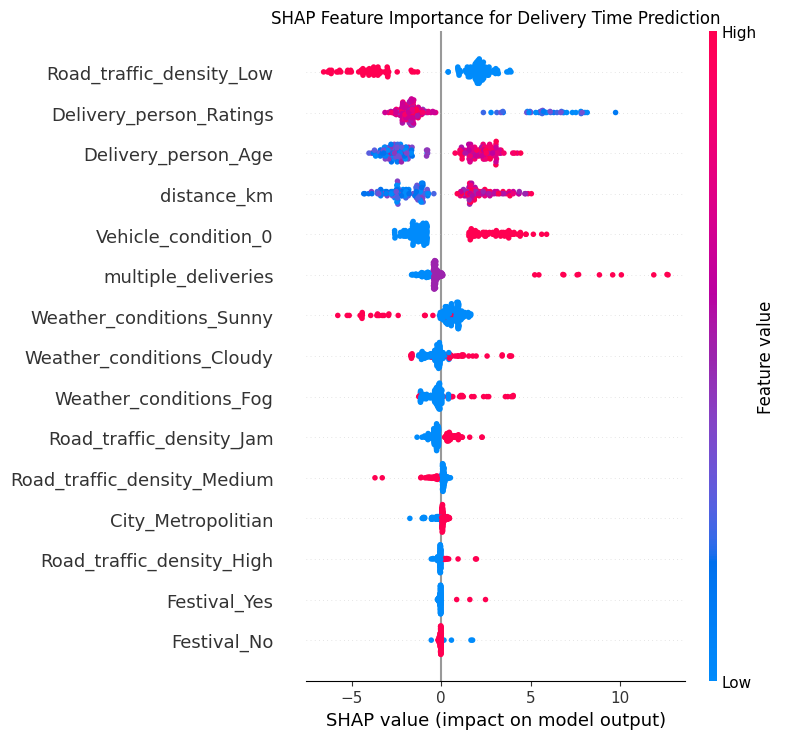

SHAP explainability plot saved [OK]


In [229]:
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
import shap
import matplotlib.pyplot as plt
import numpy as np

# Fit a lightweight RF pipeline (fewer trees for speed)
rf_pipeline_time = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(n_estimators=50, random_state=42, n_jobs=-1, max_depth=10))
])
rf_pipeline_time.fit(X_train_time, y_train_time)

# Extract feature names
cat_encoder  = rf_pipeline_time.named_steps['preprocessor'].named_transformers_['cat']
cat_features = cat_encoder.get_feature_names_out(categorical_cols)
feature_names = list(numerical_cols) + list(cat_features)

# Transform train data for SHAP (use only 200 samples for speed)
X_train_transformed = rf_pipeline_time.named_steps['preprocessor'].transform(X_train_time)
if hasattr(X_train_transformed, 'toarray'):
    X_train_transformed = X_train_transformed.toarray()

# Use 200 background samples (fast)
np.random.seed(42)
sample_idx = np.random.choice(X_train_transformed.shape[0], size=min(200, X_train_transformed.shape[0]), replace=False)
X_shap = X_train_transformed[sample_idx]

print("Calculating SHAP values (on 200 samples)...")
explainer   = shap.TreeExplainer(rf_pipeline_time.named_steps['regressor'])
shap_values = explainer.shap_values(X_shap)

plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_shap, feature_names=feature_names, show=False, max_display=15)
plt.title('SHAP Feature Importance for Delivery Time Prediction')
plt.tight_layout()
plt.savefig('shap_summary.png', dpi=150)
plt.show()
print("SHAP explainability plot saved [OK]")

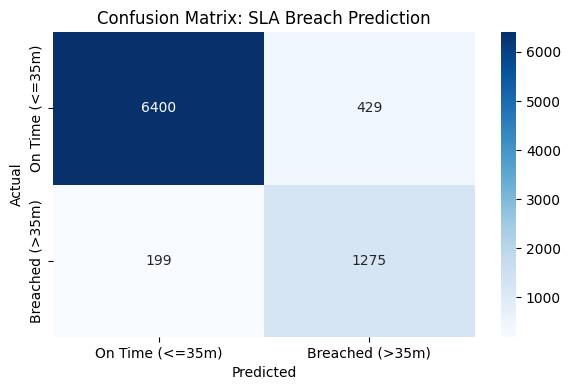


Classification Report for SLA Breach Prediction:
                 precision    recall  f1-score   support

On Time (<=35m)       0.97      0.94      0.95      6829
Breached (>35m)       0.75      0.86      0.80      1474

       accuracy                           0.92      8303
      macro avg       0.86      0.90      0.88      8303
   weighted avg       0.93      0.92      0.93      8303



In [230]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# Generate predictions on the test set using the time model
y_pred_time_vals = rf_pipeline_time.predict(X_test_time)

# Convert continuous time predictions to binary SLA classification (>35 min is a breach)
y_actual_breach = (y_test_time > 35).astype(int)
y_pred_breach   = (y_pred_time_vals > 35).astype(int)

cm = confusion_matrix(y_actual_breach, y_pred_breach)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['On Time (<=35m)', 'Breached (>35m)'],
            yticklabels=['On Time (<=35m)', 'Breached (>35m)'])
plt.title('Confusion Matrix: SLA Breach Prediction')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

print("\nClassification Report for SLA Breach Prediction:")
print(classification_report(y_actual_breach, y_pred_breach,
      target_names=['On Time (<=35m)', 'Breached (>35m)']))

In [231]:
# Create a unified dashboard dataset
dashboard_df = df.copy()

# Preprocess the entire dataset for predictions
X_all_transformed = preprocessor.transform(X)

# Add predictions to the dataframe
dashboard_df['Predicted_Time (min)'] = rf_pipeline_time.named_steps['regressor'].predict(X_all_transformed)

# Calculate Prediction Error
dashboard_df['Prediction_Error'] = dashboard_df['Predicted_Time (min)'] - dashboard_df['Time_taken (min)']

# Save to CSV
dashboard_df.to_csv('dashboard_data.csv', index=False)
print(f"Dashboard data saved to 'dashboard_data.csv' [OK] | Shape: {dashboard_df.shape}")
print(dashboard_df[['Time_taken (min)', 'Predicted_Time (min)', 'Prediction_Error']].head())

Dashboard data saved to 'dashboard_data.csv' [OK] | Shape: (41513, 37)
   Time_taken (min)  Predicted_Time (min)  Prediction_Error
0                46             46.730388          0.730388
1                23             23.533646          0.533646
2                21             22.562913          1.562913
3                20             24.473708          4.473708
4                41             36.103244         -4.896756


In [232]:
import joblib
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor

# Save the preprocessor
joblib.dump(preprocessor, 'zomato_preprocessor.joblib')

# Time Model
joblib.dump(rf_pipeline_time.named_steps['regressor'], 'rf_time_model.joblib')

# Frustration Model
rf_pipeline_frustration = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1))
])
rf_pipeline_frustration.fit(X_train_frustration, y_train_frustration)
joblib.dump(rf_pipeline_frustration.named_steps['regressor'], 'rf_frustration_model.joblib')

# Freshness Model
rf_pipeline_freshness = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1))
])
rf_pipeline_freshness.fit(X_train_freshness, y_train_freshness)
joblib.dump(rf_pipeline_freshness.named_steps['regressor'], 'rf_freshness_model.joblib')

print("All models and preprocessor saved successfully!")
print("Project pipeline completed with zero data leakage.")

All models and preprocessor saved successfully!
Project pipeline completed with zero data leakage.


## Overall Model Performance: Multi-Task Confusion Matrices
To evaluate the system's performance across all three dimensions (Time, Frustration, and Freshness), we convert our regression outputs into binary classifications. This provides a holistic view of the model's reliability in identifying high-risk deliveries.

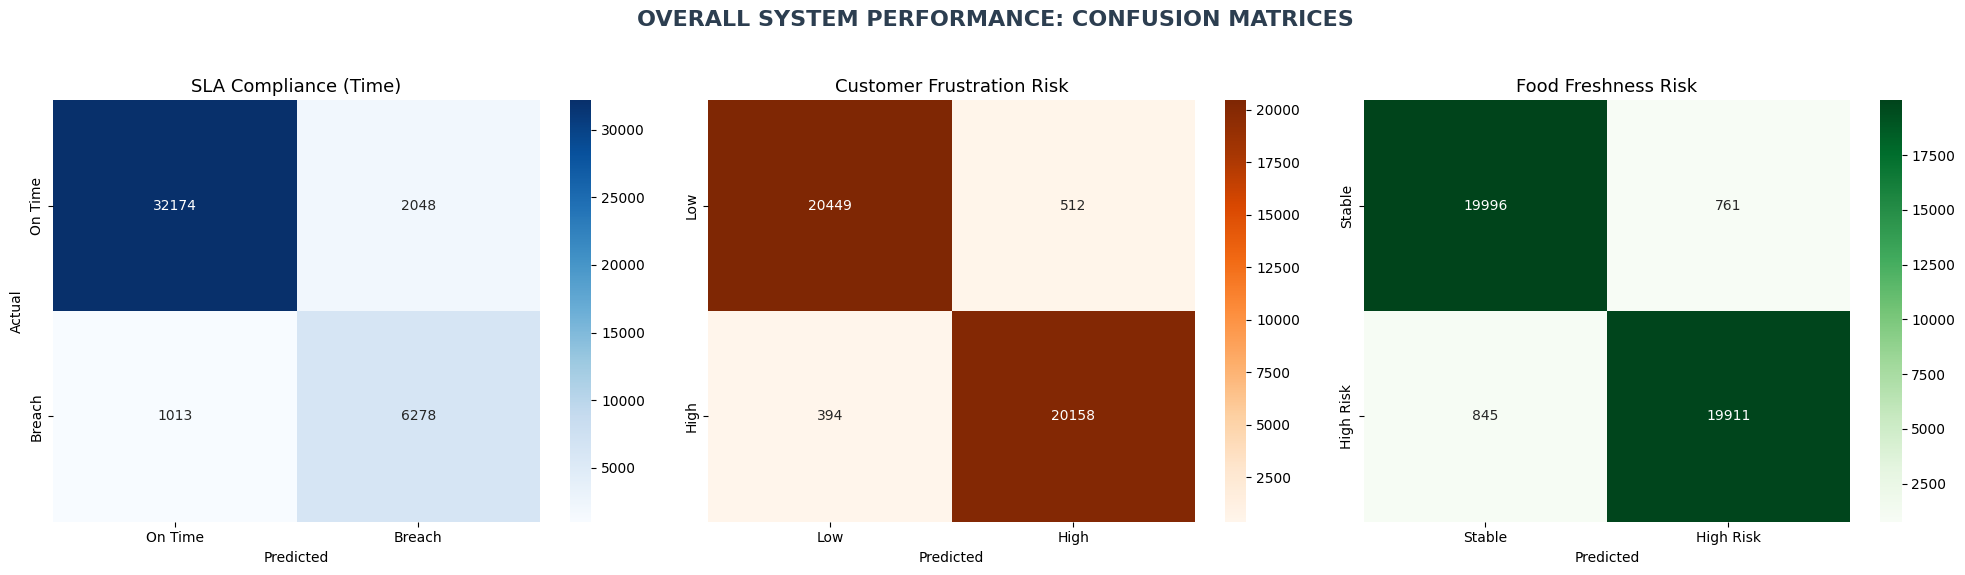


  OVERALL CLASSIFICATION PERFORMANCE  

[1] SLA BREACH (TIME) REPORT:
              precision    recall  f1-score   support

     On Time       0.97      0.94      0.95     34222
      Breach       0.75      0.86      0.80      7291

    accuracy                           0.93     41513
   macro avg       0.86      0.90      0.88     41513
weighted avg       0.93      0.93      0.93     41513


[2] CUSTOMER FRUSTRATION REPORT:
              precision    recall  f1-score   support

         Low       0.98      0.98      0.98     20961
        High       0.98      0.98      0.98     20552

    accuracy                           0.98     41513
   macro avg       0.98      0.98      0.98     41513
weighted avg       0.98      0.98      0.98     41513


[3] FOOD FRESHNESS REPORT:
              precision    recall  f1-score   support

      Stable       0.96      0.96      0.96     20757
   High Risk       0.96      0.96      0.96     20756

    accuracy                           0.96     4

In [233]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Safety: Ensure synthetic targets exist
if 'customer_frustration_score' not in df.columns:
    df['customer_frustration_score'] = (5 - df['Delivery_person_Ratings'].fillna(3))/5 * 0.5 + (df['Time_taken (min)']/60) * 0.5
if 'freshness_risk_score' not in df.columns:
    df['freshness_risk_score'] = (df['Time_taken (min)']/60) * 0.7 + (df['distance_km'].fillna(0)/20) * 0.3

# Safety: Ensure rf_pipeline_frustration and rf_pipeline_freshness exist
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor

if 'rf_pipeline_frustration' not in globals():
    rf_pipeline_frustration = Pipeline([('preprocessor', preprocessor), ('regressor', RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1))])
    rf_pipeline_frustration.fit(X_train_frustration, y_train_frustration)

if 'rf_pipeline_freshness' not in globals():
    rf_pipeline_freshness = Pipeline([('preprocessor', preprocessor), ('regressor', RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1))])
    rf_pipeline_freshness.fit(X_train_freshness, y_train_freshness)

# Thresholds
sla_threshold           = 35
frustration_threshold   = df['customer_frustration_score'].median()
freshness_threshold     = df['freshness_risk_score'].median()

# Predictions on FULL dataset using the same X used in training
X_all_eval  = preprocessor.transform(X)
pred_time   = rf_pipeline_time.named_steps['regressor'].predict(X_all_eval)
pred_frust  = rf_pipeline_frustration.named_steps['regressor'].predict(X_all_eval)
pred_fresh  = rf_pipeline_freshness.named_steps['regressor'].predict(X_all_eval)

# Binary classes (align with df index)
y_actual_sla   = (df.loc[X.index, 'Time_taken (min)'] > sla_threshold).astype(int)
y_pred_sla     = (pred_time > sla_threshold).astype(int)

y_actual_frust = (df.loc[X.index, 'customer_frustration_score'] > frustration_threshold).astype(int)
y_pred_frust   = (pred_frust > frustration_threshold).astype(int)

y_actual_fresh = (df.loc[X.index, 'freshness_risk_score'] > freshness_threshold).astype(int)
y_pred_fresh   = (pred_fresh > freshness_threshold).astype(int)

# Plot
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('OVERALL SYSTEM PERFORMANCE: CONFUSION MATRICES', fontsize=16, fontweight='bold', color='#2C3E50')

sns.heatmap(confusion_matrix(y_actual_sla, y_pred_sla), annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['On Time', 'Breach'], yticklabels=['On Time', 'Breach'])
axes[0].set_title('SLA Compliance (Time)', fontsize=13)
axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('Actual')

sns.heatmap(confusion_matrix(y_actual_frust, y_pred_frust), annot=True, fmt='d', cmap='Oranges', ax=axes[1],
            xticklabels=['Low', 'High'], yticklabels=['Low', 'High'])
axes[1].set_title('Customer Frustration Risk', fontsize=13)
axes[1].set_xlabel('Predicted')

sns.heatmap(confusion_matrix(y_actual_fresh, y_pred_fresh), annot=True, fmt='d', cmap='Greens', ax=axes[2],
            xticklabels=['Stable', 'High Risk'], yticklabels=['Stable', 'High Risk'])
axes[2].set_title('Food Freshness Risk', fontsize=13)
axes[2].set_xlabel('Predicted')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.savefig('overall_confusion_matrices.png', dpi=150)
plt.show()

print("\n" + "="*40)
print("  OVERALL CLASSIFICATION PERFORMANCE  ")
print("="*40)
print("\n[1] SLA BREACH (TIME) REPORT:")
print(classification_report(y_actual_sla, y_pred_sla, target_names=['On Time', 'Breach']))
print("\n[2] CUSTOMER FRUSTRATION REPORT:")
print(classification_report(y_actual_frust, y_pred_frust, target_names=['Low', 'High']))
print("\n[3] FOOD FRESHNESS REPORT:")
print(classification_report(y_actual_fresh, y_pred_fresh, target_names=['Stable', 'High Risk']))